# YOLO11m + U-Net++ Wound Detection and Segmentation

**Objective:** Two-stage pipeline for wound detection and segmentation.
Stage 1: YOLO11m-seg detects wound bounding boxes + coarse masks.
Stage 2: U-Net++ (EfficientNet-B3) refines segmentation on cropped ROIs.

**Dataset:** `data/wound_focus_clean/` with pre-built train / val / test splits.

**Outputs:** checkpoints, training curves, metrics, qualitative predictions,
and markdown reports — all under `experiments/YOLO11m_UNetPP/`.

## 1: Setup / Imports / Configuration

In [1]:
%matplotlib inline

import json
import sys
import time
import platform
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

SCRIPT_DIR = Path.cwd().resolve()
PROJECT_ROOT = SCRIPT_DIR.parent.parent
sys.path.insert(0, str(SCRIPT_DIR))

from pipeline_utils import (
    set_seed,
    get_device,
    load_config,
    prepare_yolo_dataset,
    validate_yolo_dataset,
    create_unet_datasets,
    make_unet_dataloaders,
    unet_collate_fn,
    WoundDataset,
    IMAGENET_MEAN,
    IMAGENET_STD,
    WOUND_ONLY_CLASSES,
)
from train_model import (
    build_yolo_model,
    train_yolo,
    evaluate_yolo,
    predict_yolo,
    build_unet_model,
    BCEDiceLoss,
    train_one_epoch_unet,
    validate_one_epoch_unet,
    evaluate_unet_metrics,
    save_unet_checkpoint,
    load_unet_checkpoint,
    save_unet_training_curves,
    combined_inference,
    evaluate_combined,
    calculate_wound_area,
    predict_single_image,
    generate_report,
    save_global_metrics_summary,
    display_results_curves,
    display_results_predictions,
)

print("=" * 60)
print("Libraries imported successfully")
print("=" * 60)
print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
print("=" * 60)

# Load configuration
CONFIG = load_config(SCRIPT_DIR / "config.yaml")
set_seed(CONFIG.get("seed", 42))
device = get_device()

# Resolve paths
output_dir = SCRIPT_DIR / "checkpoints"
results_dir = SCRIPT_DIR / "results"
reports_dir = SCRIPT_DIR / "reports"
for d in [output_dir, results_dir, reports_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f"\nDevice: {device}")
print(f"\nConfiguration:")
for section in ["yolo", "unet", "combined"]:
    print(f"\n  [{section.upper()}]")
    for k, v in CONFIG.get(section, {}).items():
        print(f"    {k}: {v}")

Libraries imported successfully
PyTorch: 2.5.1+cu121
CUDA:    True
GPU:     NVIDIA GeForce RTX 4060 Laptop GPU

Device: cuda

Configuration:

  [YOLO]
    model: yolo11m-seg.pt
    image_size: 640
    batch_size: 8
    epochs: 100
    lr0: 0.01
    lrf: 0.01
    optimizer: SGD
    momentum: 0.937
    weight_decay: 0.0005
    patience: 20
    degrees: 10
    perspective: 0.0
    flipud: 0.5
    fliplr: 0.5
    mosaic: 1.0
    mixup: 0.1
    hsv_h: 0.015
    hsv_s: 0.7
    hsv_v: 0.4

  [UNET]
    encoder: efficientnet-b3
    encoder_weights: imagenet
    input_size: [256, 256]
    in_channels: 3
    classes: 1
    batch_size: 16
    epochs: 50
    lr: 0.0001
    weight_decay: 0.0001
    optimizer: AdamW
    scheduler: CosineAnnealingLR
    scheduler_T_max: 50
    scheduler_eta_min: 1e-06
    early_stop_patience: 10
    loss_bce_weight: 0.5
    loss_dice_weight: 0.5
    roi_padding: 0.1

  [COMBINED]
    yolo_conf_thresh: 0.5
    unet_mask_thresh: 0.5
    roi_padding: 0.1
    pixels_per_

## 2: Dataset Validation and Loading

In [2]:
# ============================================================================
# 2.1 Convert COCO annotations to YOLO segmentation format
# ============================================================================

print("Converting COCO -> YOLO label format...")
dataset_yaml = prepare_yolo_dataset(CONFIG, SCRIPT_DIR)
print(f"\nDataset YAML: {dataset_yaml}")

print("\nValidating YOLO dataset...")
is_valid = validate_yolo_dataset(dataset_yaml)
if not is_valid:
    raise RuntimeError("YOLO dataset validation FAILED.")
print()

# ============================================================================
# 2.2 Create U-Net++ ROI datasets and dataloaders
# ============================================================================

print("Creating U-Net++ ROI datasets...")
unet_train_ds, unet_val_ds, unet_test_ds = create_unet_datasets(CONFIG, SCRIPT_DIR)
print(f"  ROI samples — Train: {len(unet_train_ds)}, Val: {len(unet_val_ds)}, Test: {len(unet_test_ds)}")

unet_cfg = CONFIG["unet"]
unet_train_loader, unet_val_loader = make_unet_dataloaders(
    unet_train_ds, unet_val_ds,
    batch_size=unet_cfg.get("batch_size", 16),
    num_workers=CONFIG.get("num_workers", 0),
)
unet_test_loader = torch.utils.data.DataLoader(
    unet_test_ds,
    batch_size=unet_cfg.get("batch_size", 16),
    shuffle=False,
    num_workers=CONFIG.get("num_workers", 0),
    pin_memory=torch.cuda.is_available(),
    collate_fn=unet_collate_fn,
)

# ============================================================================
# 2.3 Create evaluation dataset (full images for combined pipeline)
# ============================================================================

data_root = (PROJECT_ROOT / CONFIG["data_root"]).resolve()
test_ann = (PROJECT_ROOT / CONFIG["ann_test"]).resolve()
eval_dataset = WoundDataset(
    root=str(data_root),
    annotation_file=str(test_ann),
    image_size=(CONFIG["yolo"].get("image_size", 640), CONFIG["yolo"].get("image_size", 640)),
)
print(f"  Full-image test set: {len(eval_dataset)} images")

Converting COCO -> YOLO label format...
  Converting train (train_wound_only.json) ...
    -> 257 label files written to E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\labels
  Converting val (val_wound_only.json) ...
    -> 57 label files written to E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\labels
  Converting test (test_wound_only.json) ...
    -> 55 label files written to E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\labels

Dataset YAML: E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\yolo_data\dataset.yaml

Validating YOLO dataset...
[OK] train: 257 images listed, spot-check passed
[OK] train: YOLO label paths (images->labels) exist; 50/50 sample .txt non-empty
[OK] val: 57 images listed, spot-check passed
[OK] val: YOLO label paths (images->labels) exist; 50/50 sample .txt non-empty
[OK] test: 55 images listed, spot-check passed
[OK] test: YOLO label paths (images->labels) exist; 50/50 sample .txt no

## 3: Sample Visualization and Model Initialization

In [3]:
# ============================================================================
# 3.1 Visualize U-Net++ ROI training samples with GT masks
# ============================================================================

NUM_VIS = 4
fig, axes = plt.subplots(2, NUM_VIS, figsize=(4 * NUM_VIS, 8))

mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t = torch.tensor(IMAGENET_STD).view(3, 1, 1)

for idx in range(min(NUM_VIS, len(unet_train_ds))):
    img_tensor, mask_tensor = unet_train_ds[idx]
    img_np = (img_tensor * std_t + mean_t).permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)
    mask_np = mask_tensor.squeeze().cpu().numpy()

    axes[0, idx].imshow(img_np)
    axes[0, idx].set_title(f"ROI crop {idx}")
    axes[0, idx].axis("off")

    axes[1, idx].imshow(mask_np, cmap="gray")
    axes[1, idx].set_title(f"GT mask {idx}")
    axes[1, idx].axis("off")

fig.suptitle("U-Net++ Training ROIs with Ground-Truth Masks", fontsize=13)
fig.tight_layout()
plt.show()

# ============================================================================
# 3.2 Build models
# ============================================================================

print("\nBuilding YOLO11m-seg model...")
yolo_model = build_yolo_model(CONFIG["yolo"].get("model", "yolo11m-seg.pt"))
print(f"  YOLO model loaded: {CONFIG['yolo'].get('model', 'yolo11m-seg.pt')}")

print("\nBuilding U-Net++ model...")
unet_model = build_unet_model(CONFIG)
unet_model.to(device)
n_params = sum(p.numel() for p in unet_model.parameters())
print(f"  U-Net++ on {device} ({n_params:,} parameters)")
print(f"  Encoder: {CONFIG['unet']['encoder']} | Input: {CONFIG['unet']['input_size']}")

C:\Users\Ul8ziz\AppData\Local\Temp\ipykernel_43804\2914492637.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



Building YOLO11m-seg model...
  YOLO model loaded: yolo11m-seg.pt

Building U-Net++ model...
  U-Net++ on cuda (13,624,793 parameters)
  Encoder: efficientnet-b3 | Input: [256, 256]


## 4: Training Loop / Validation / Checkpoints

In [4]:
# ============================================================================
# 4.1 Stage 1 — YOLO11m-seg training
# ============================================================================

print("Starting Stage 1: YOLO11m-seg Training")
print("=" * 60)

yolo_results = train_yolo(CONFIG, SCRIPT_DIR)
yolo_test_metrics = evaluate_yolo(CONFIG, SCRIPT_DIR)
yolo_results.update(yolo_test_metrics)

print("\n" + "=" * 60)
print("YOLO Training Complete")
print("=" * 60)
for k, v in yolo_test_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

# ============================================================================
# 4.2 Stage 2 — U-Net++ training loop
# ============================================================================

print("\n\nStarting Stage 2: U-Net++ Training")
print("=" * 60)

unet_cfg = CONFIG["unet"]
criterion = BCEDiceLoss(
    bce_weight=unet_cfg.get("loss_bce_weight", 0.5),
    dice_weight=unet_cfg.get("loss_dice_weight", 0.5),
)
optimizer = torch.optim.AdamW(
    unet_model.parameters(),
    lr=unet_cfg.get("lr", 1e-4),
    weight_decay=unet_cfg.get("weight_decay", 1e-4),
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=unet_cfg.get("scheduler_T_max", 50),
    eta_min=unet_cfg.get("scheduler_eta_min", 1e-6),
)

epochs = unet_cfg.get("epochs", 50)
patience = unet_cfg.get("early_stop_patience", 10)
ckpt_unet = SCRIPT_DIR / "checkpoints" / "unet"
results_unet = SCRIPT_DIR / "results" / "unet"
ckpt_unet.mkdir(parents=True, exist_ok=True)
results_unet.mkdir(parents=True, exist_ok=True)

unet_history = {
    "train_losses": [],
    "val_losses": [],
    "dice_per_epoch": [],
    "iou_per_epoch": [],
}
best_dice = 0.0
best_epoch = 0
epochs_without_improve = 0

start_time = time.time()

for epoch in range(1, epochs + 1):
    print(f"\nEpoch [{epoch}/{epochs}]")
    print("-" * 40)

    train_loss = train_one_epoch_unet(
        unet_model, unet_train_loader, optimizer, criterion, device, epoch,
    )
    val_loss = validate_one_epoch_unet(unet_model, unet_val_loader, criterion, device)
    metrics = evaluate_unet_metrics(unet_model, unet_val_loader, device)

    unet_history["train_losses"].append(train_loss)
    unet_history["val_losses"].append(val_loss)
    unet_history["dice_per_epoch"].append(metrics["dice"])
    unet_history["iou_per_epoch"].append(metrics["iou"])

    print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"  Dice: {metrics['dice']:.4f} | IoU: {metrics['iou']:.4f}")

    if metrics["dice"] > best_dice:
        best_dice = metrics["dice"]
        best_epoch = epoch
        epochs_without_improve = 0
        print(f"  -> NEW BEST Dice: {best_dice:.4f}")
        save_unet_checkpoint(
            unet_model, optimizer, scheduler, epoch, metrics,
            ckpt_unet / "best_model.pth",
        )
    else:
        epochs_without_improve += 1

    save_unet_checkpoint(
        unet_model, optimizer, scheduler, epoch, metrics,
        ckpt_unet / "last_checkpoint.pth",
    )
    scheduler.step()

    if patience > 0 and epochs_without_improve >= patience:
        print(f"  Early stopping after {epochs_without_improve} epochs without improvement.")
        break

unet_training_time = time.time() - start_time

# Load best and evaluate on test
best_path = ckpt_unet / "best_model.pth"
if best_path.exists():
    load_unet_checkpoint(unet_model, best_path, device)

print("\n" + "=" * 60)
print("U-Net++ Test Evaluation")
print("=" * 60)
unet_test_metrics = evaluate_unet_metrics(unet_model, unet_test_loader, device)
for k, v in unet_test_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

unet_results_summary = {
    "best_dice": best_dice,
    "best_epoch": best_epoch,
    "training_time_s": unet_training_time,
    "test_metrics": unet_test_metrics,
    "config": unet_cfg,
}

with open(results_unet / "training_history.json", "w", encoding="utf-8") as f:
    json.dump(unet_history, f, indent=2)
with open(results_unet / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(unet_results_summary, f, indent=2, default=str)

print(f"\nBest Dice: {best_dice:.4f} at epoch {best_epoch}")
print(f"Training time: {unet_training_time:.0f}s ({unet_training_time/60:.1f} min)")

Starting Stage 1: YOLO11m-seg Training

Stage 1: Training YOLO11m-seg
Ultralytics 8.4.31  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\yolo_data\dataset.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11m-seg.pt, momentu

Saving U-Net++ training curves...
  -> Saved U-Net++ curves to E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\results\unet\unet_training_curves.png

Saving YOLO prediction samples...
  -> Saved 8 YOLO predictions to E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\results\yolo\predictions

--- Training Curves ---

--- BoxF1_curve.png ---


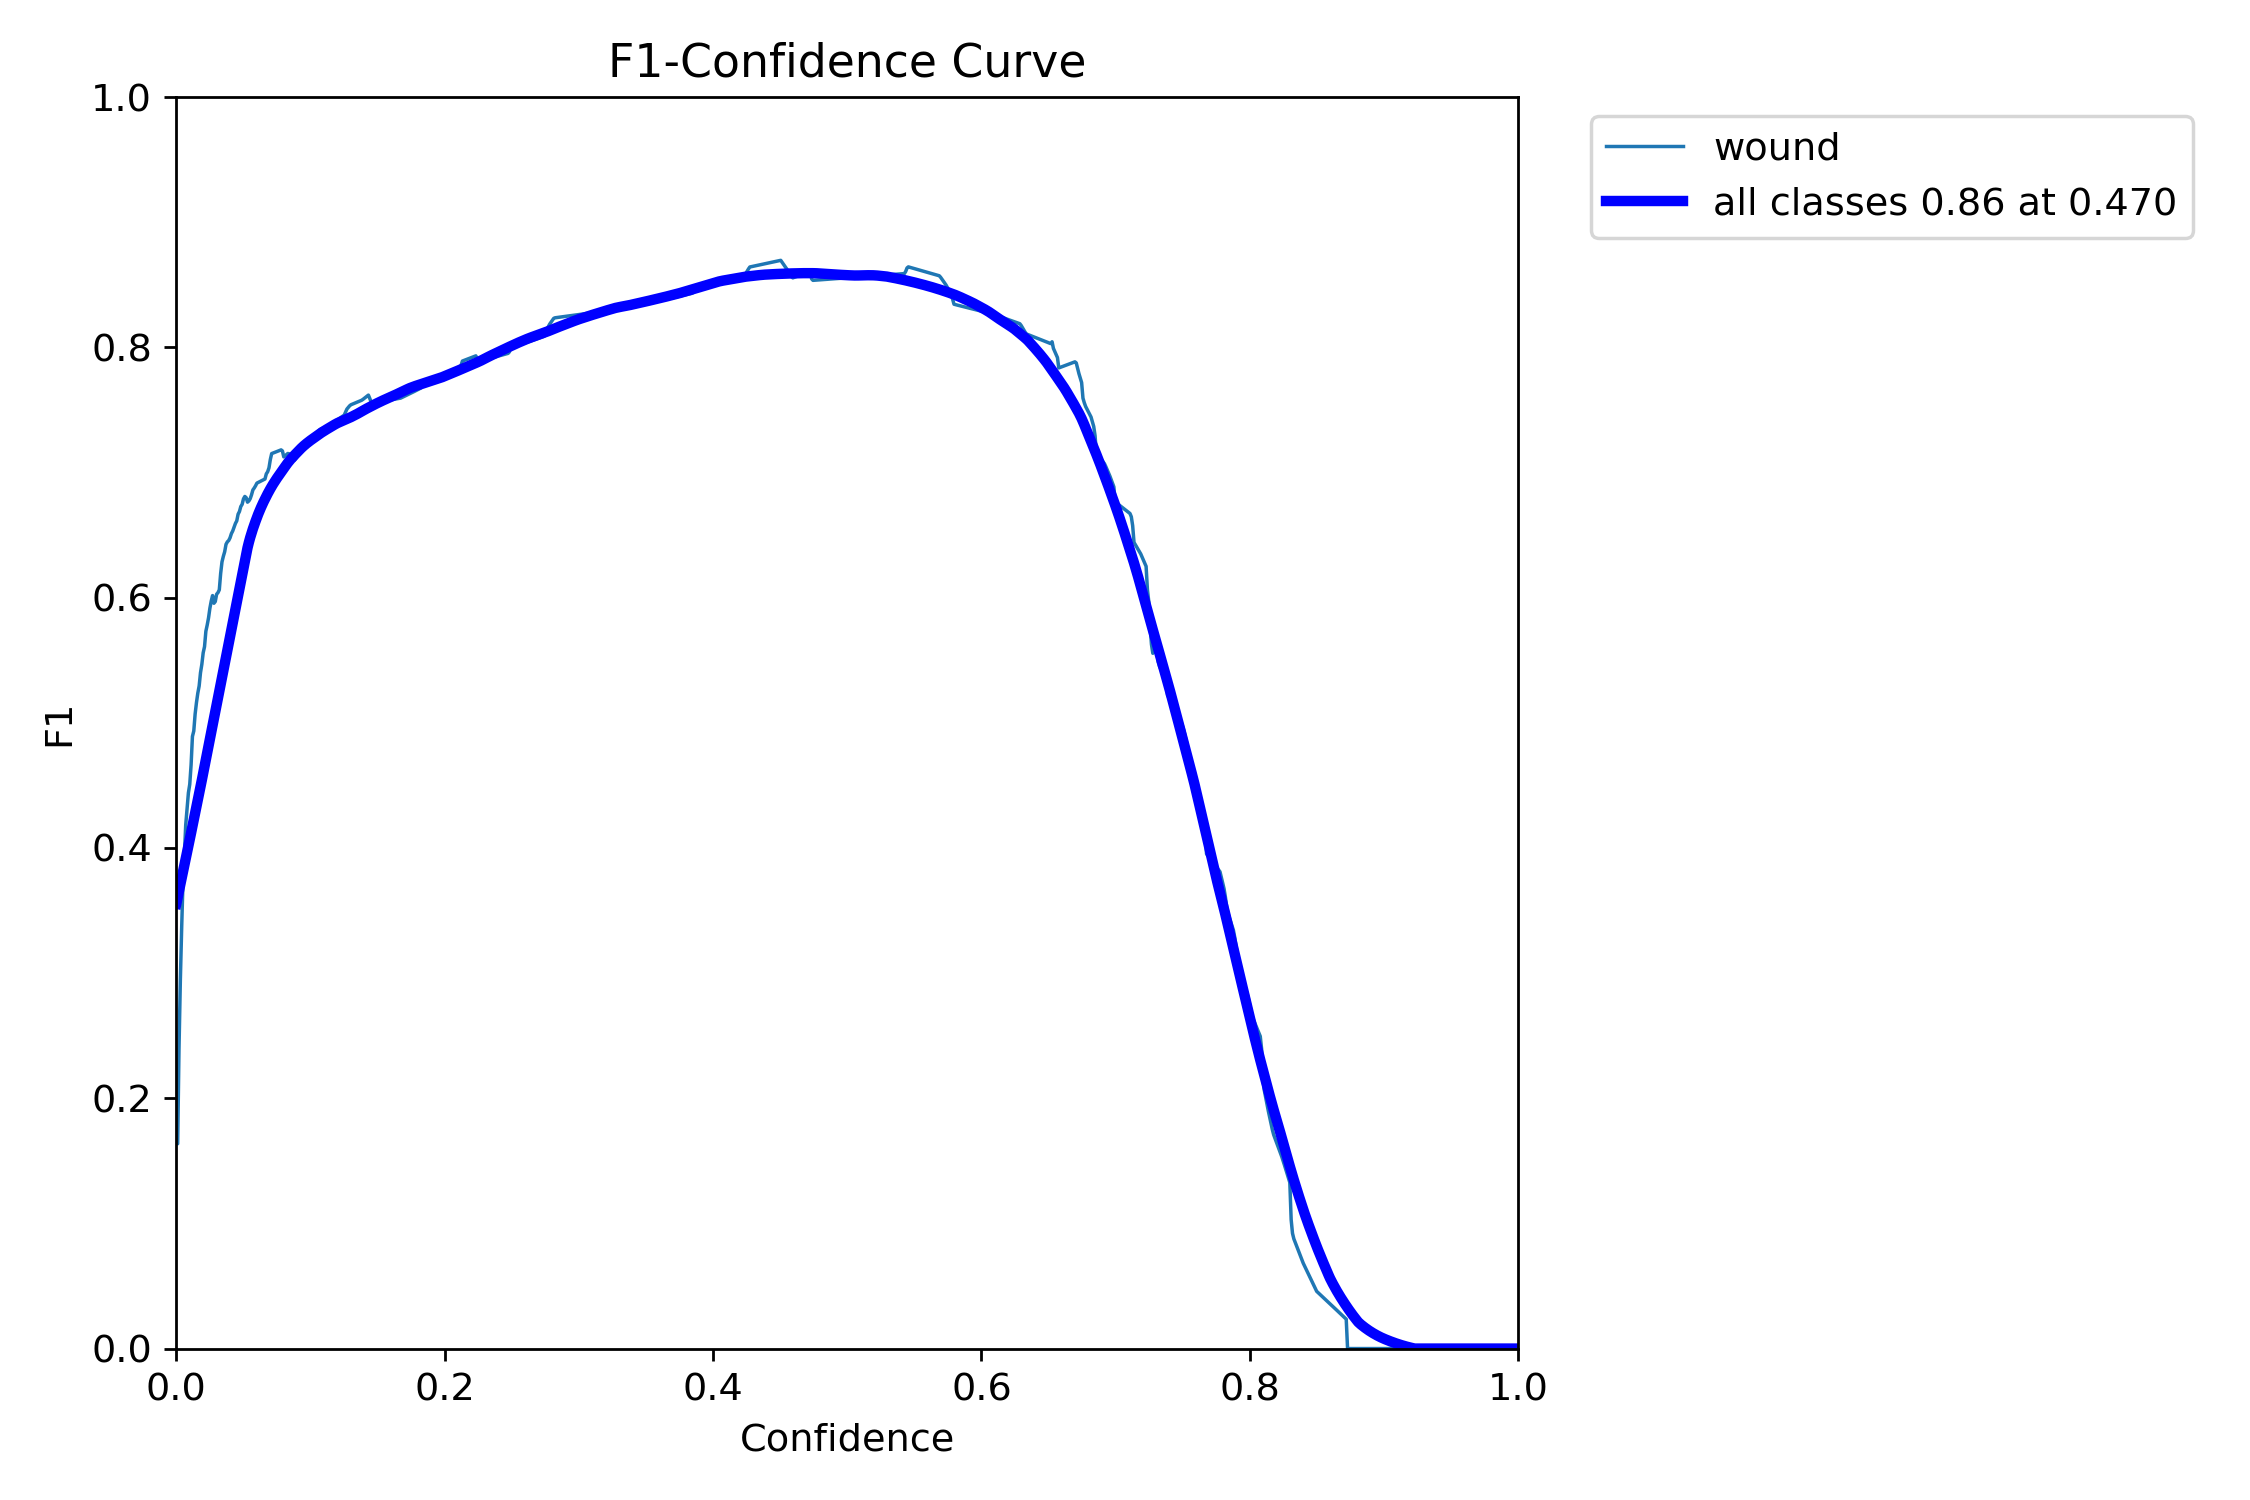


--- BoxP_curve.png ---


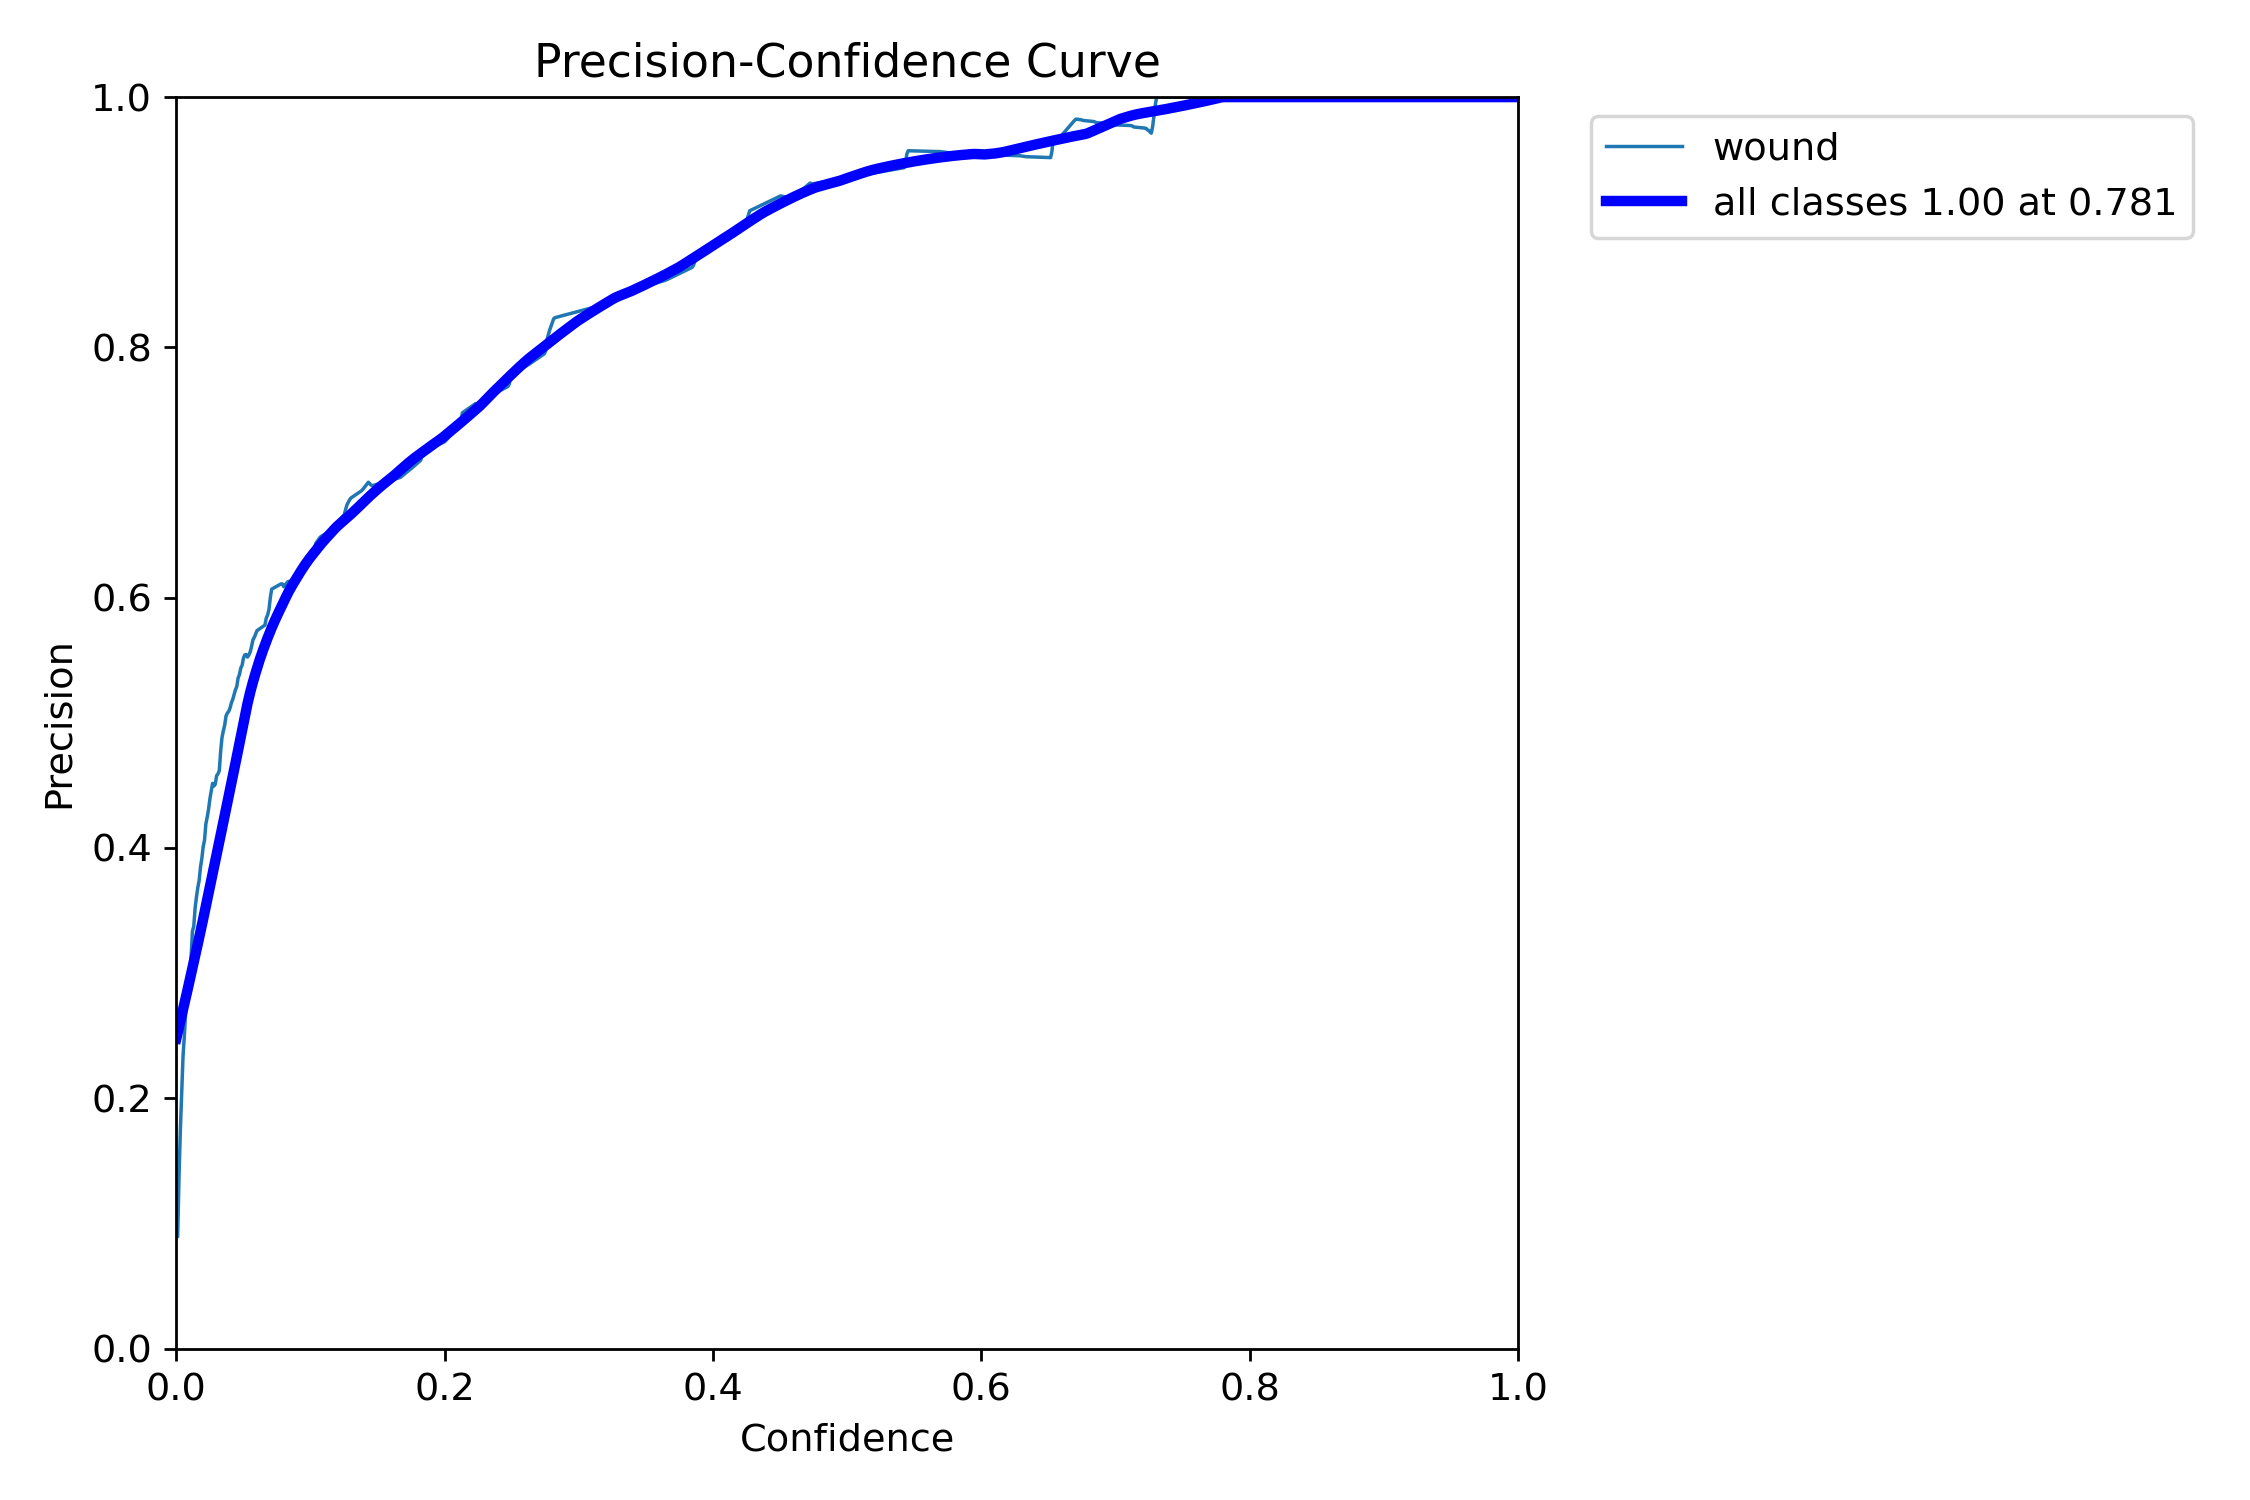


--- BoxPR_curve.png ---


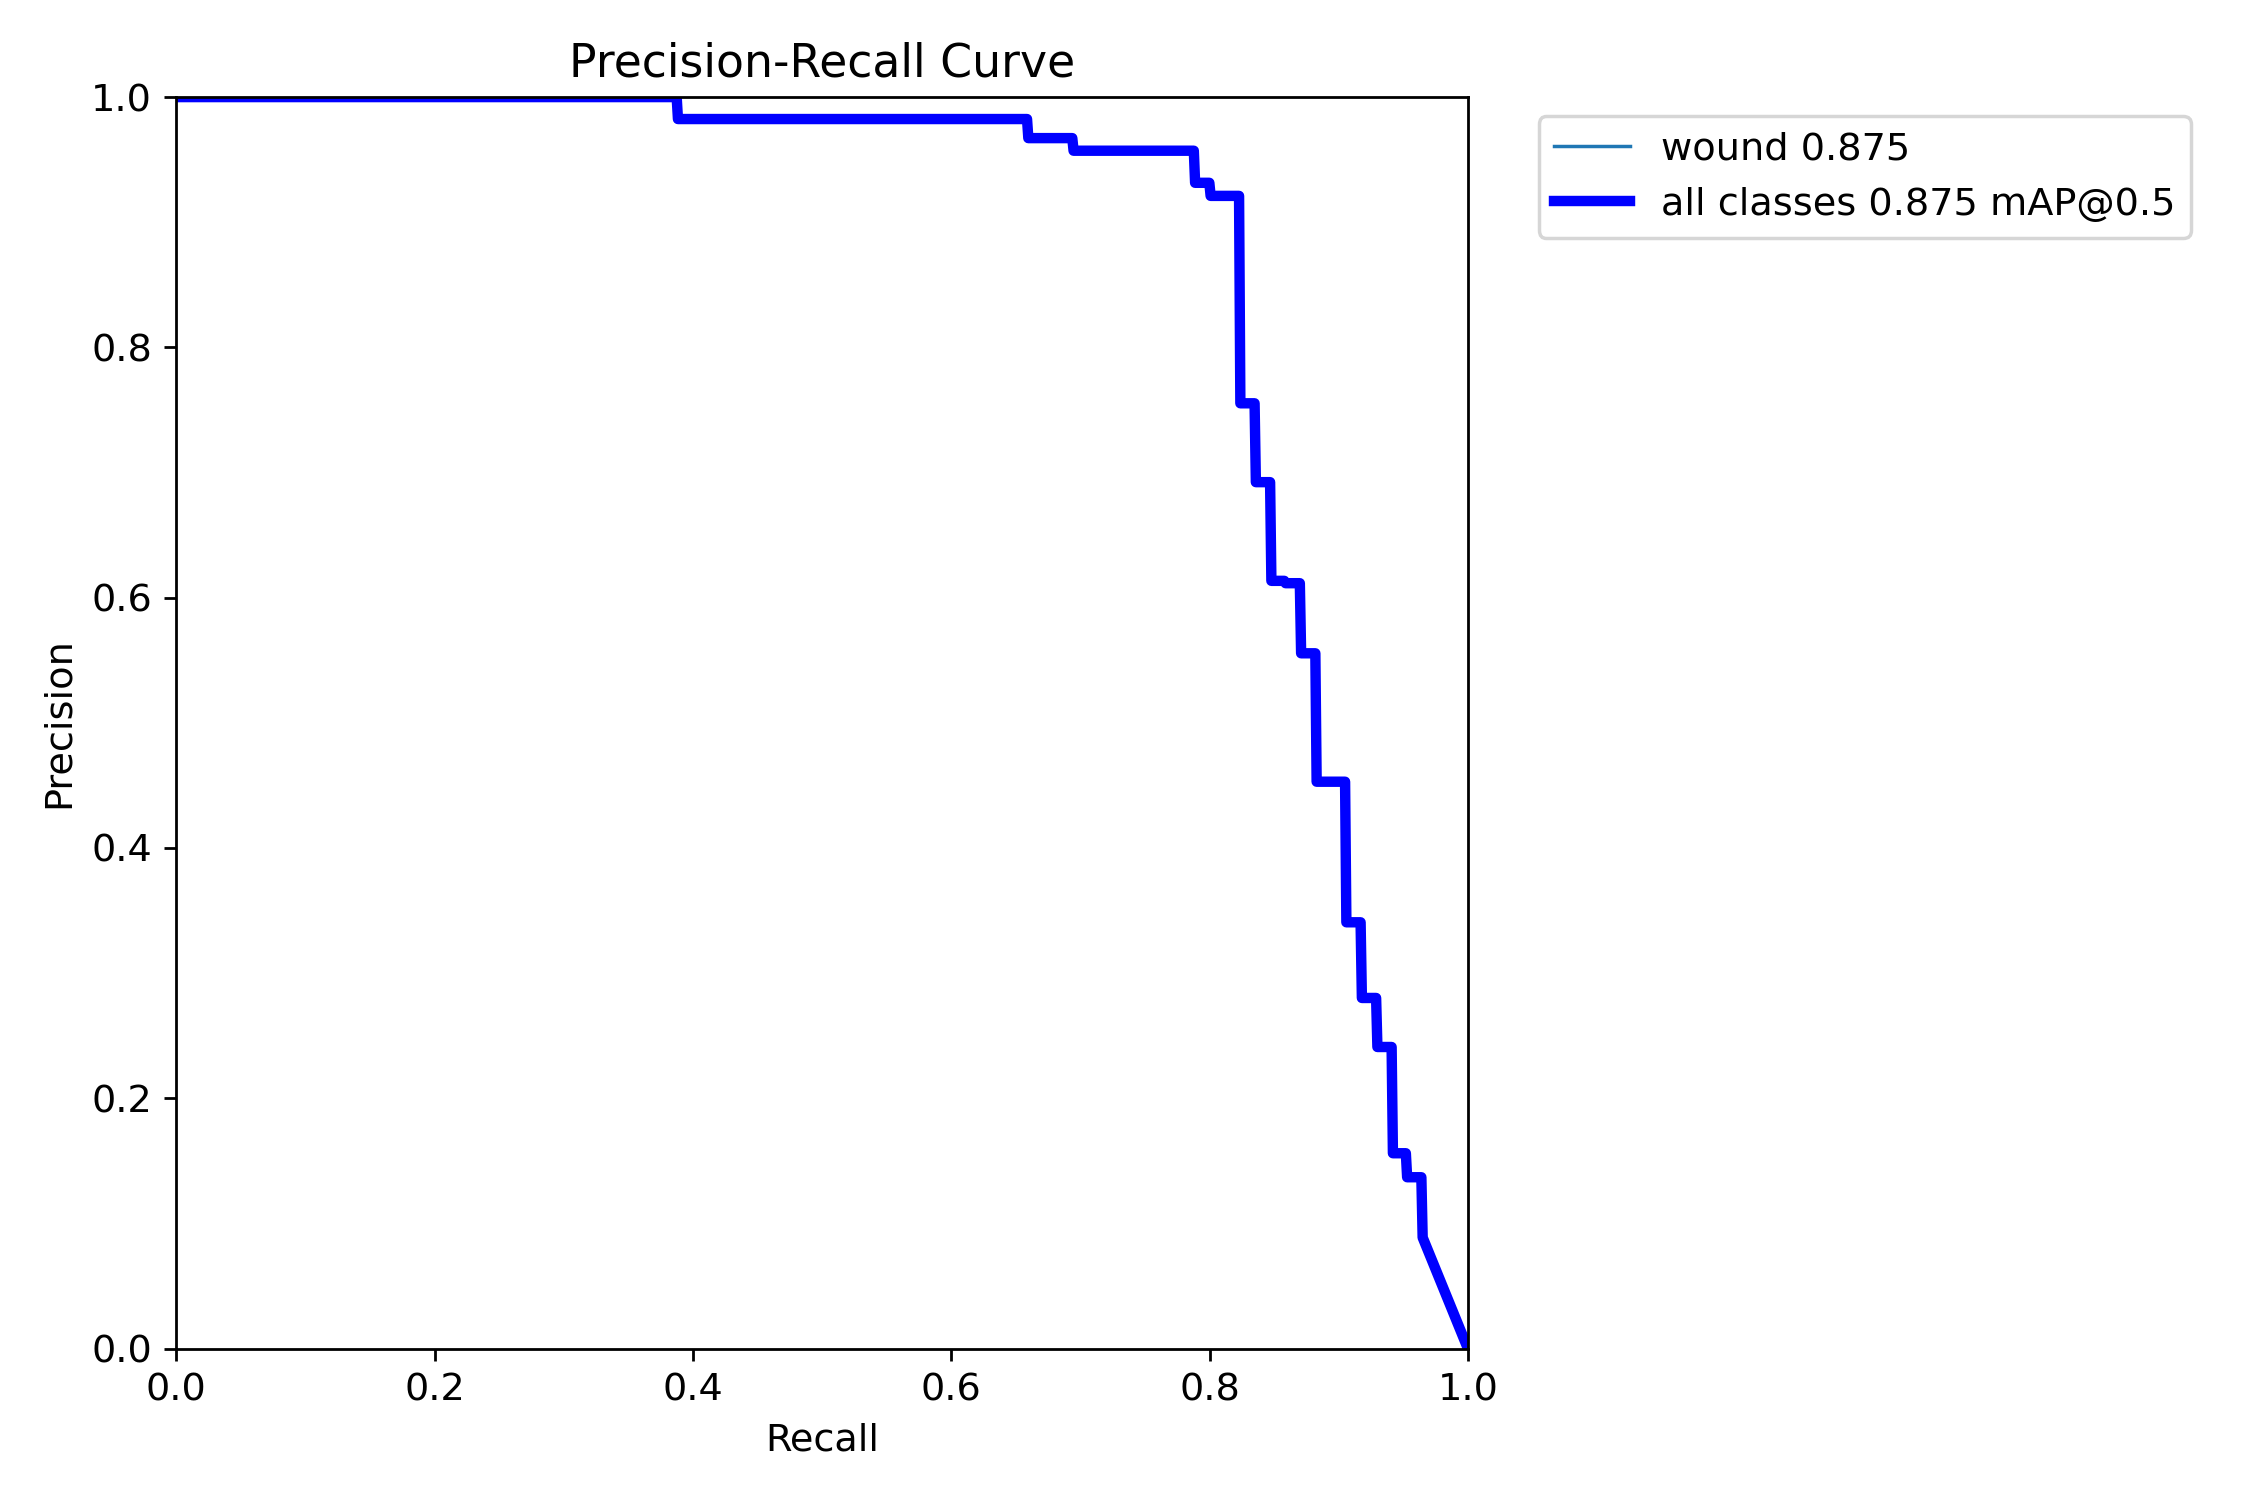


--- BoxR_curve.png ---


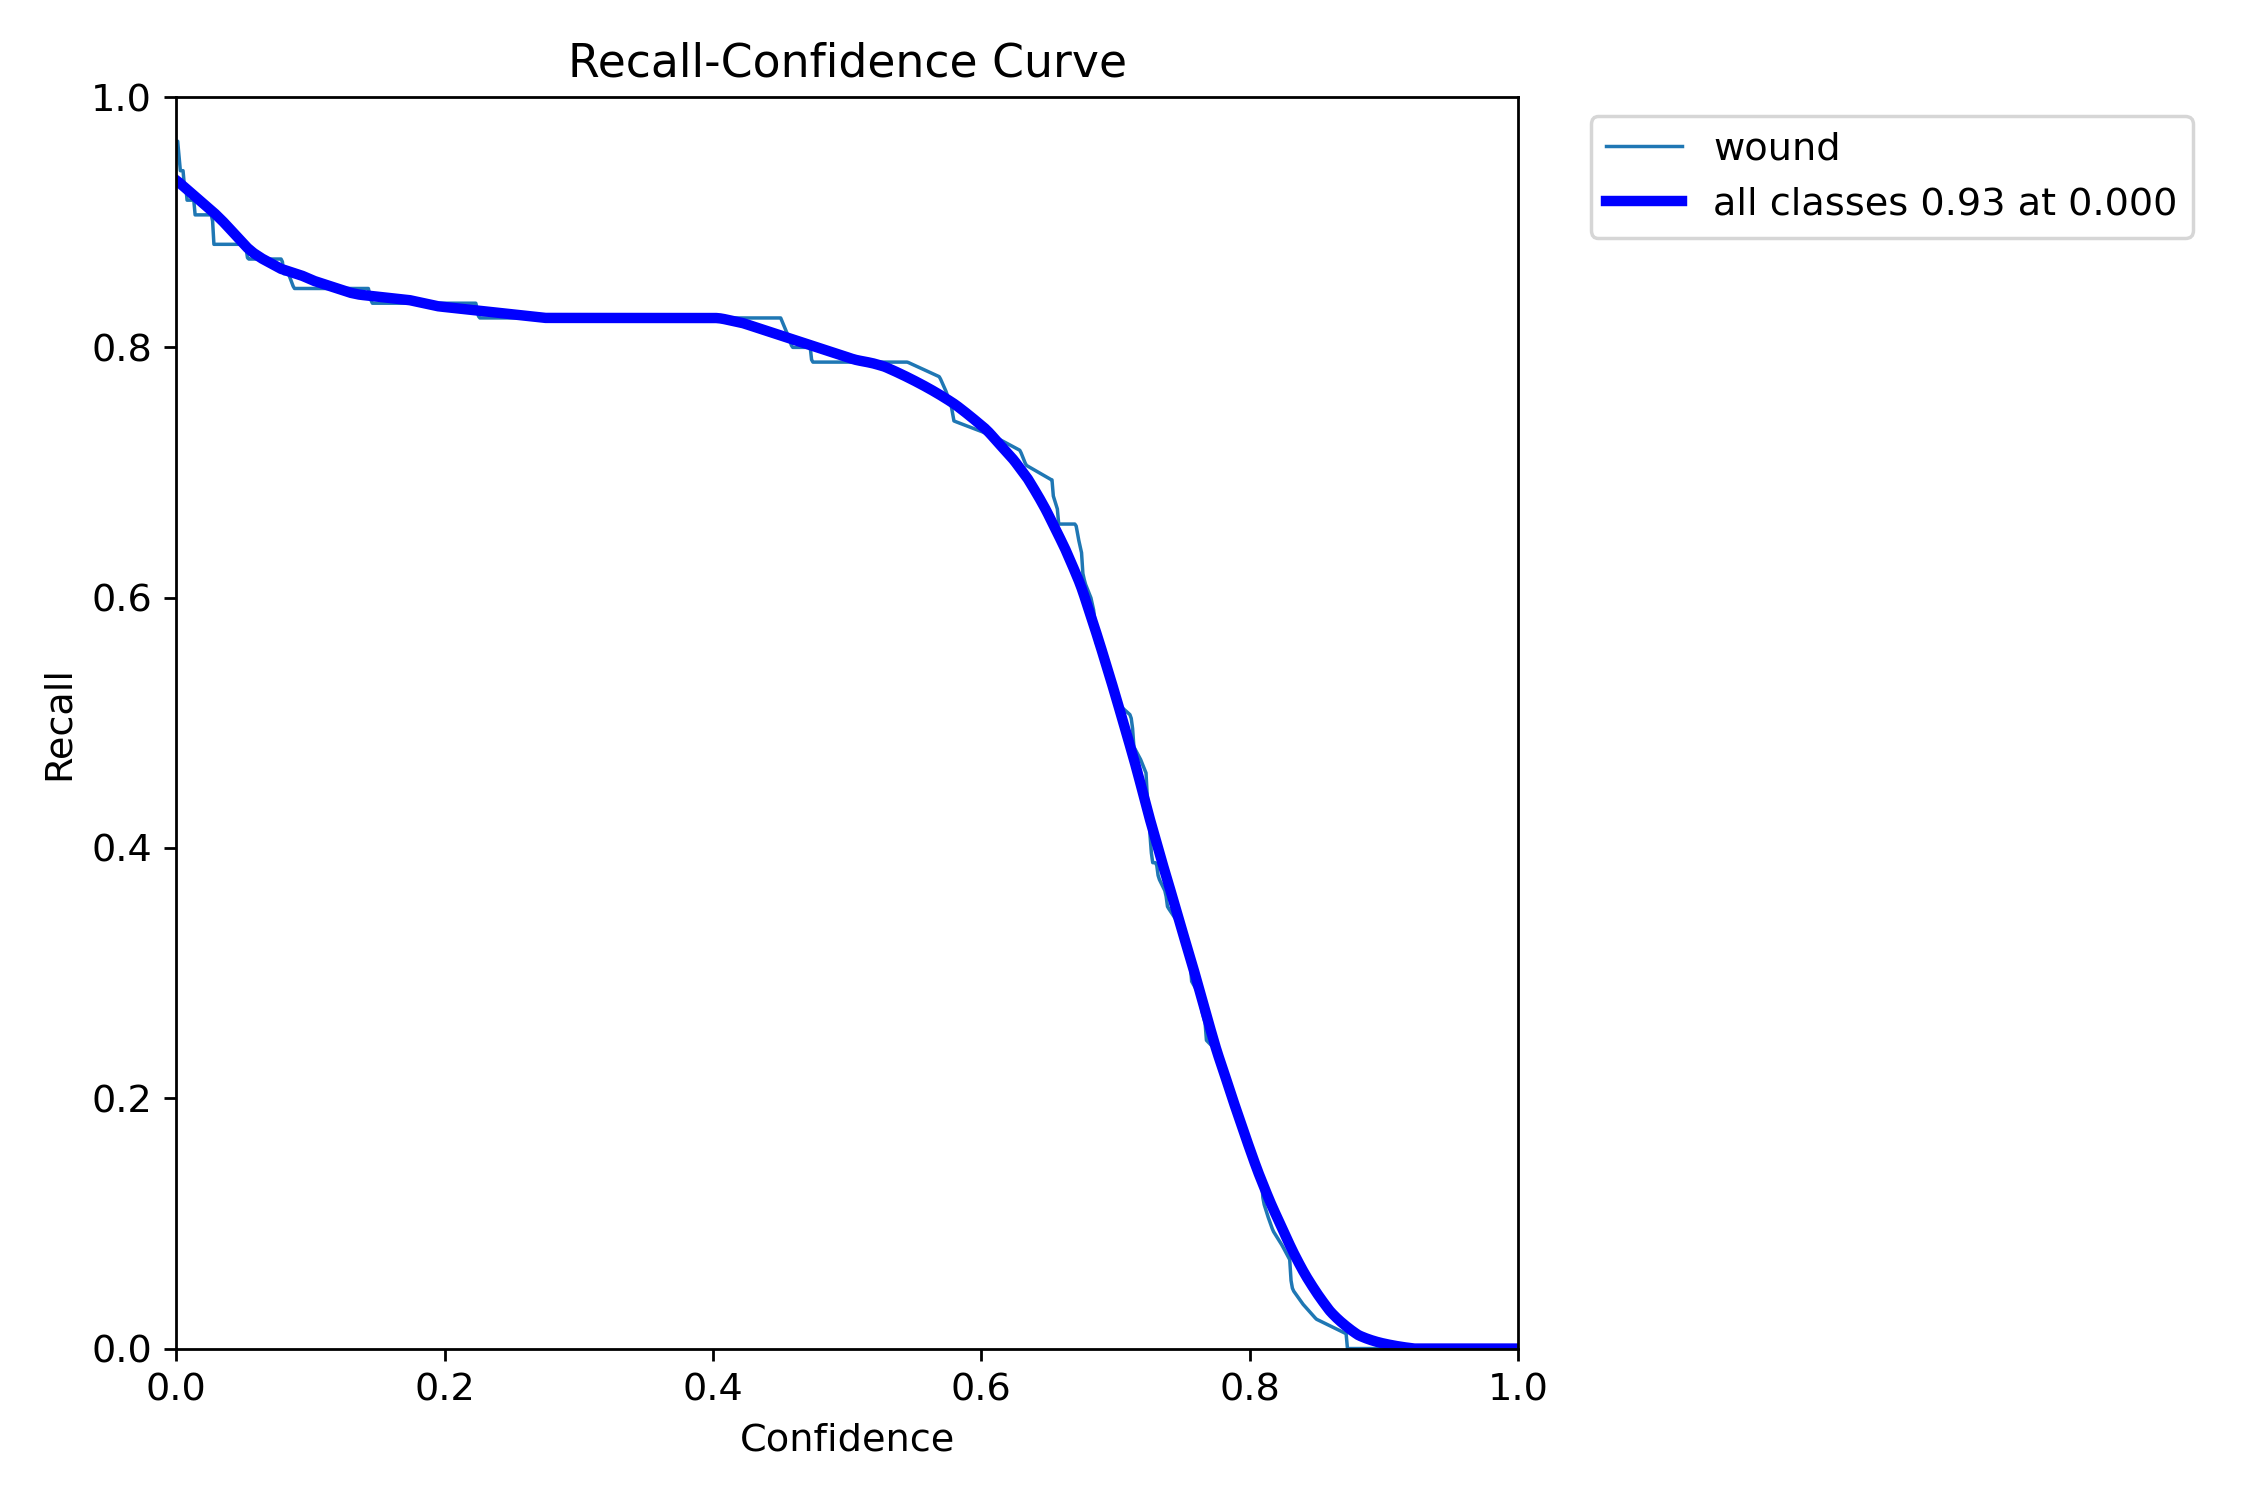


--- confusion_matrix.png ---


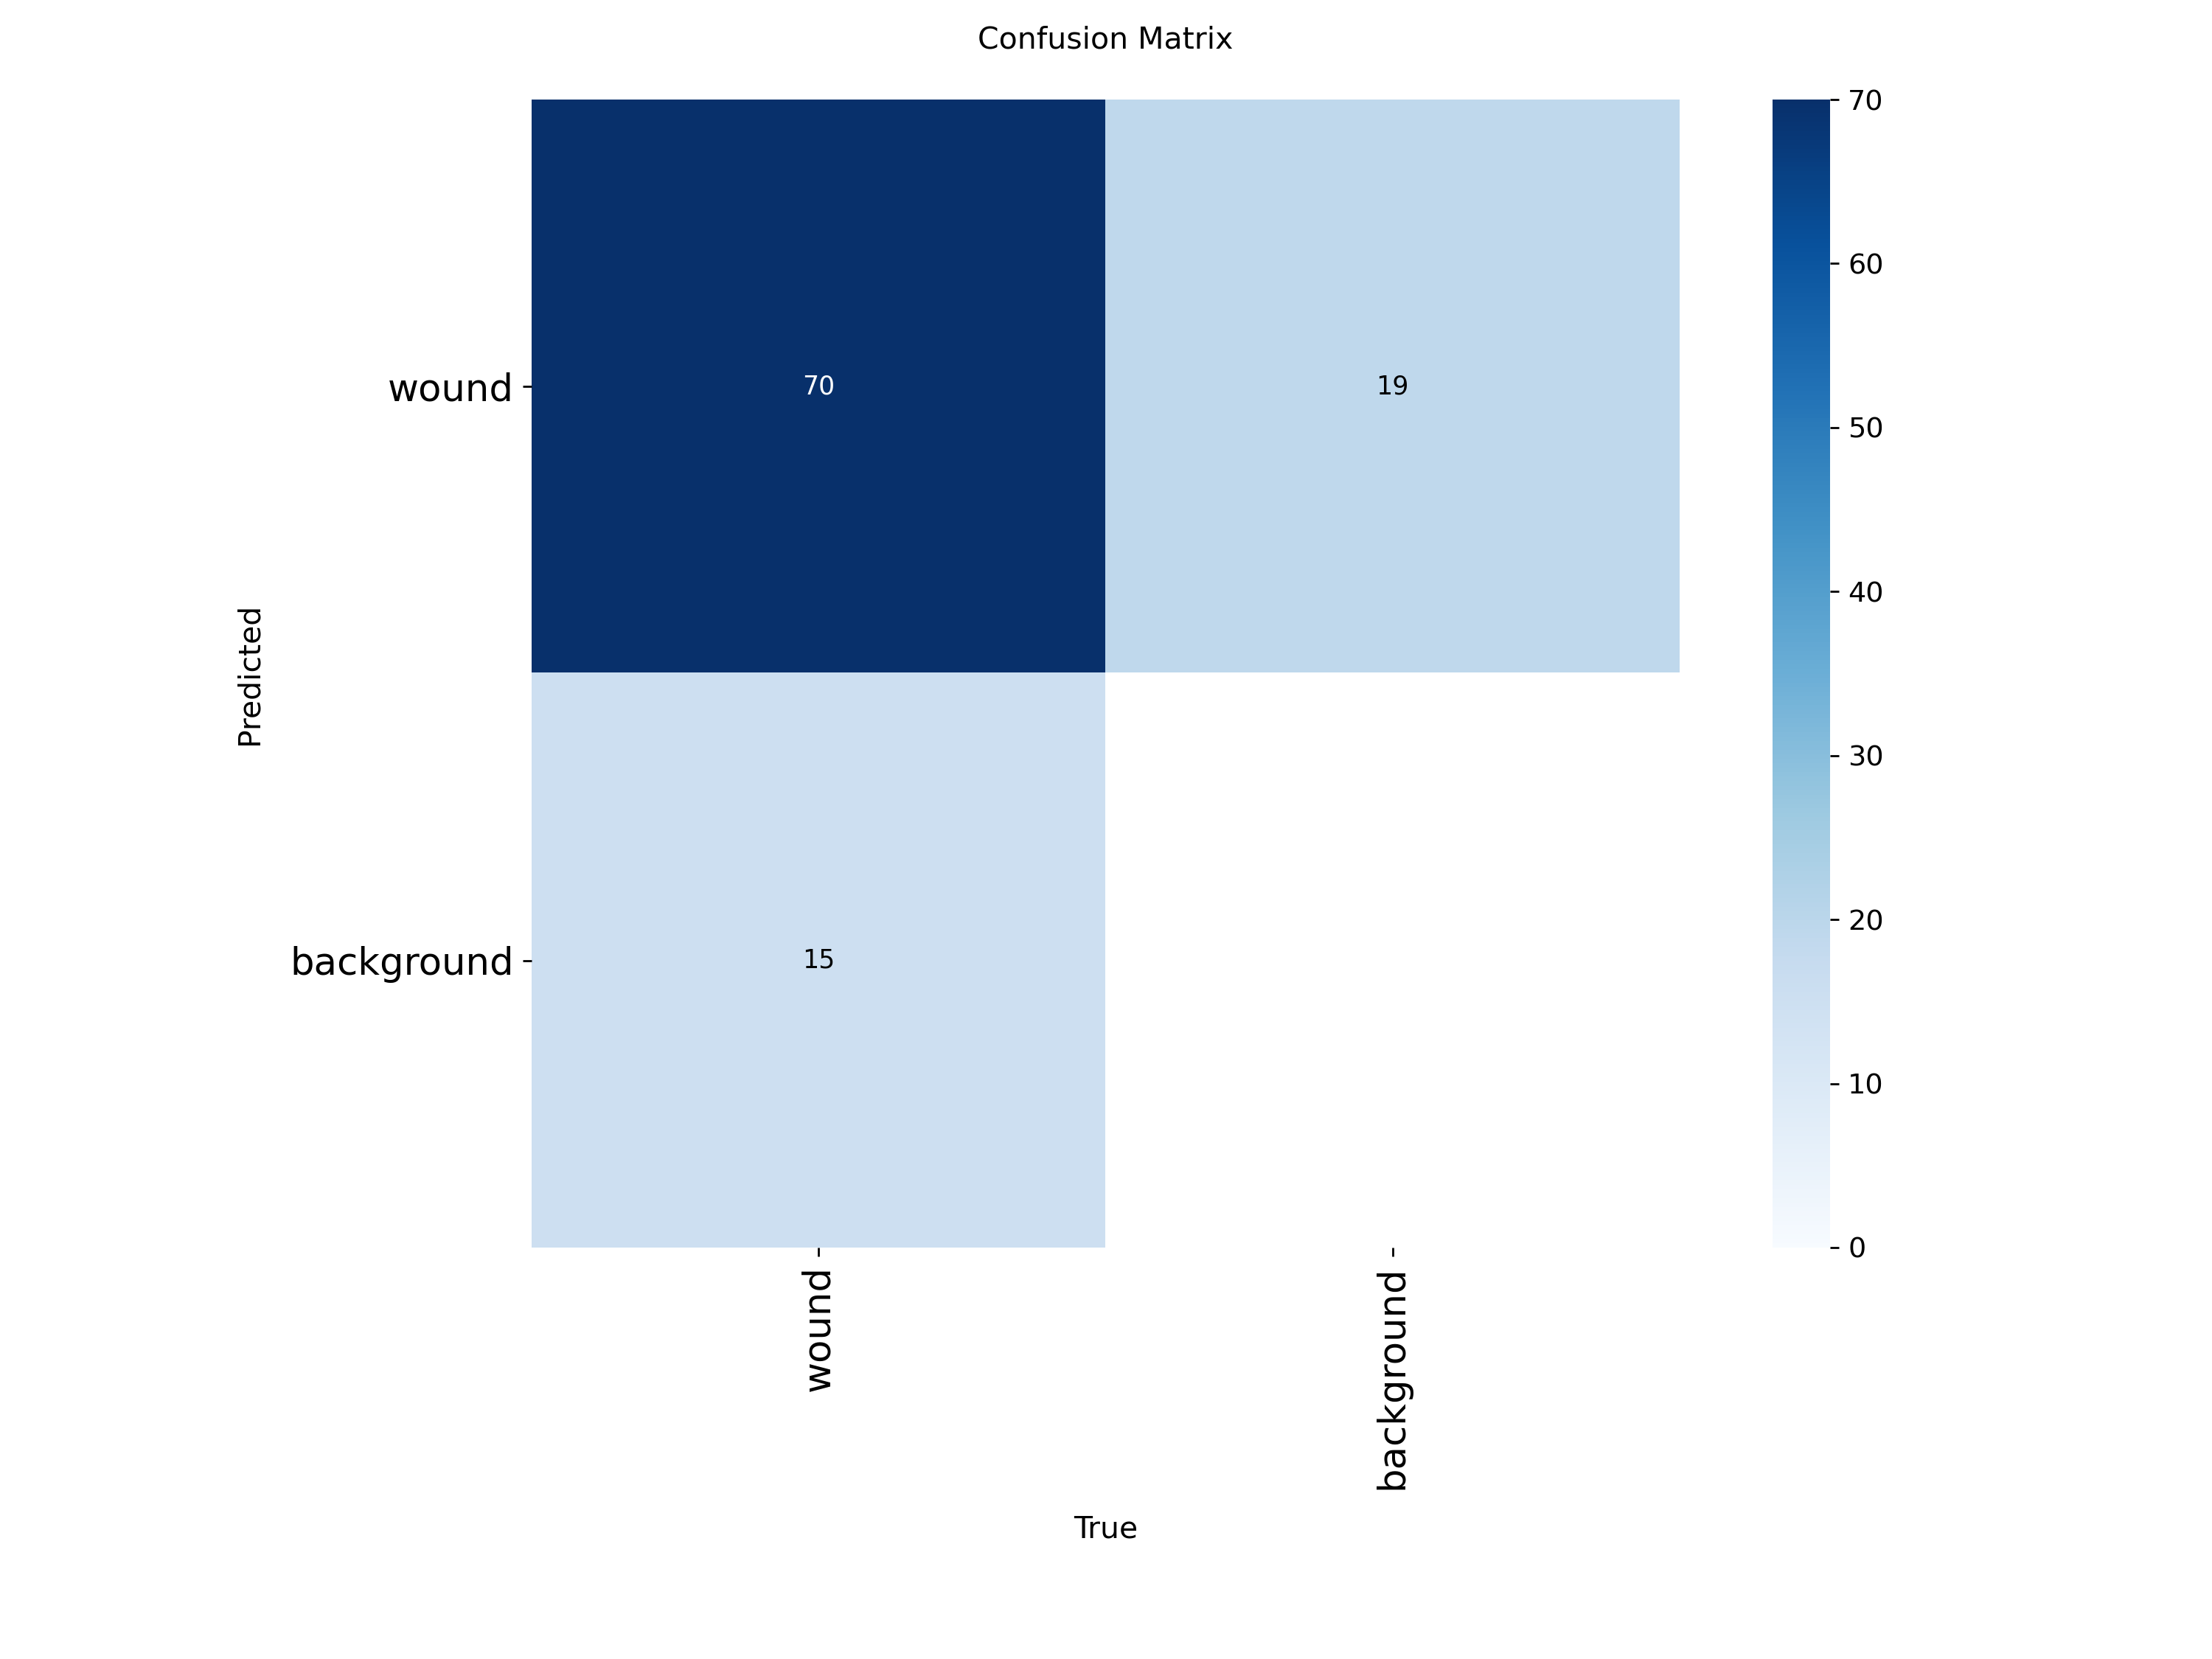


--- confusion_matrix_normalized.png ---


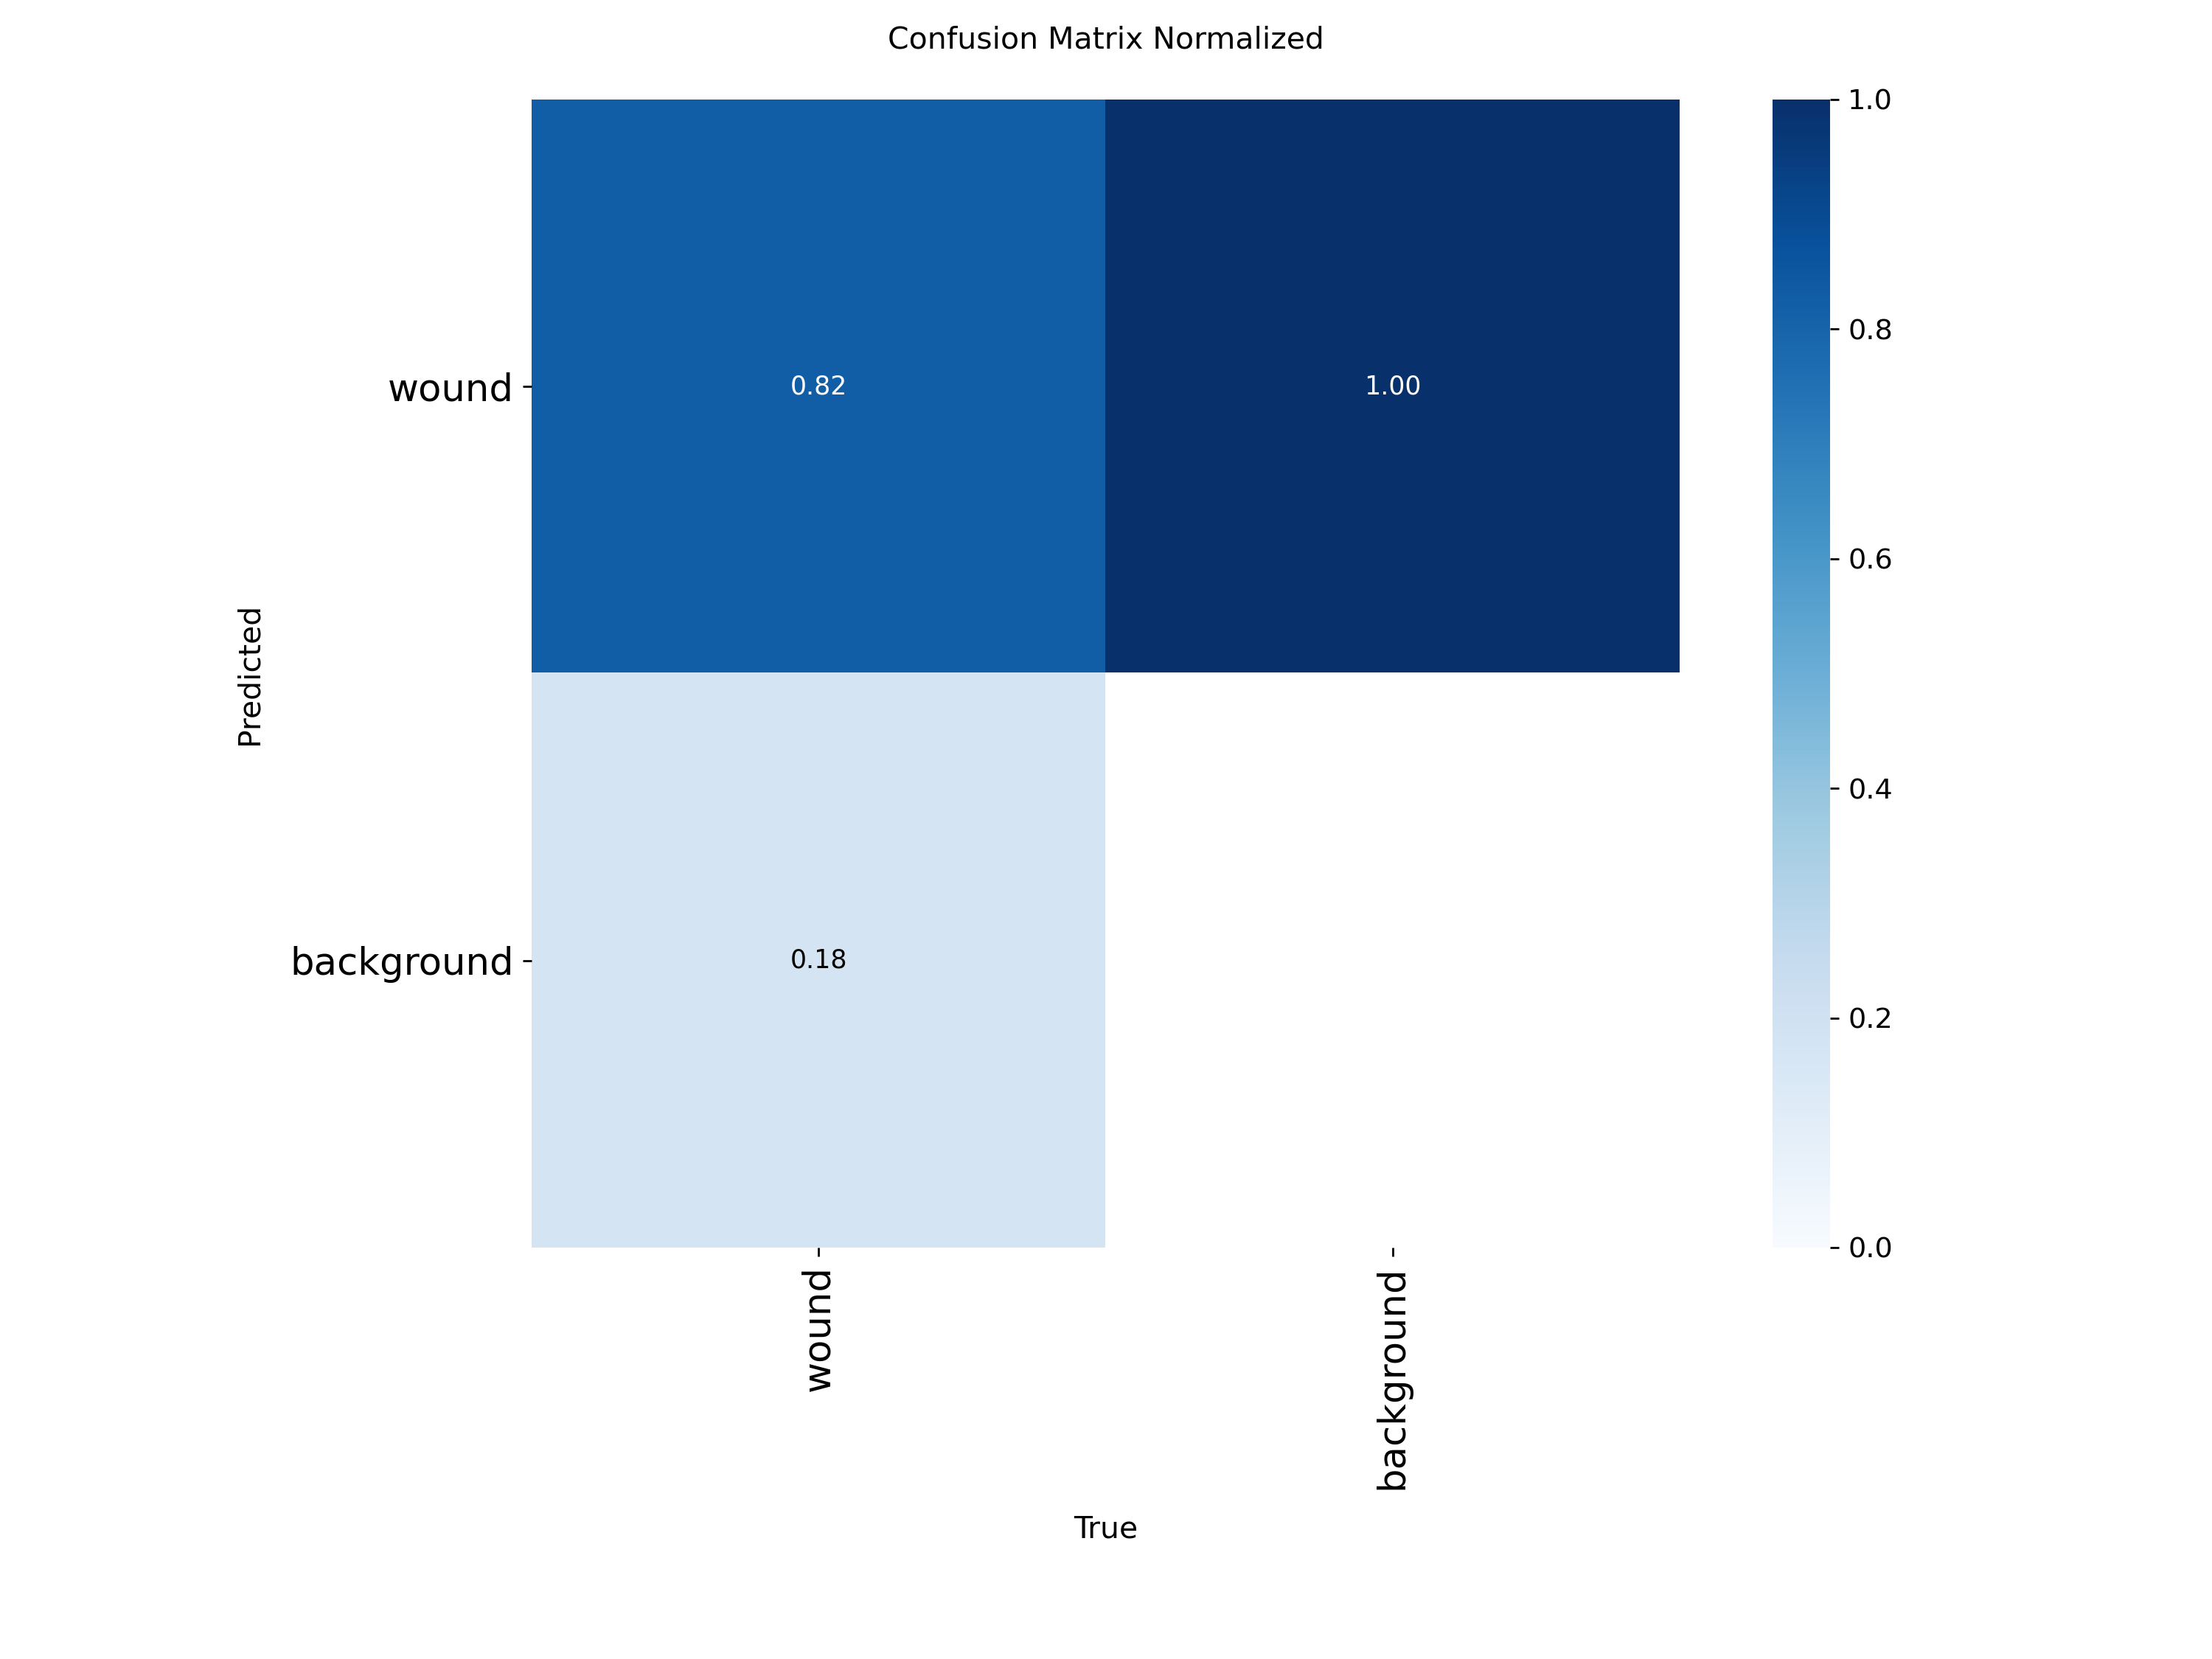

In [5]:
# ============================================================================
# Save training curves for both models
# ============================================================================

print("Saving U-Net++ training curves...")
save_unet_training_curves(unet_history, results_unet)

print("\nSaving YOLO prediction samples...")
predict_yolo(CONFIG, SCRIPT_DIR)

# Display curves inline
print("\n--- Training Curves ---")
display_results_curves(results_dir)

## 5: Qualitative Predictions / Reports / Summary

In [6]:
# ============================================================================
# 5.1 Combined inference — single image example
# ============================================================================

# Load best YOLO model for combined inference
yolo_best_path = SCRIPT_DIR / "checkpoints" / "yolo" / "best.pt"
if yolo_best_path.exists():
    yolo_model_best = build_yolo_model(str(yolo_best_path))
else:
    print("[WARNING] YOLO best.pt not found — using base model.")
    yolo_model_best = yolo_model

# Pick a test image
with open(str(test_ann), "r", encoding="utf-8") as f:
    test_coco = json.load(f)
test_images = test_coco["images"]

if test_images:
    sample_img = test_images[0]
    sample_path = str(data_root / sample_img["file_name"])

    overlay, info = predict_single_image(
        yolo_model_best, unet_model, sample_path, device, CONFIG,
    )
    print(f"File: {info['file_name']}")
    print(f"Wound area: {info.get('wound_area_cm2', 'N/A')} cm2 | "
          f"Infection: {info.get('infection', 'N/A')} | "
          f"Confidence: {info.get('confidence', 0):.2f}")

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Combined: {info.get('wound_area_cm2', '')} cm2 | {info.get('infection', '')}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# ============================================================================
# 5.2 Full combined evaluation on test set
# ============================================================================

print("\nRunning combined evaluation on full test set...")
combined_metrics = evaluate_combined(CONFIG, SCRIPT_DIR)

# ============================================================================
# 5.3 Save global metrics and generate report
# ============================================================================

save_global_metrics_summary(
    yolo_results, unet_results_summary, combined_metrics,
    CONFIG, results_dir,
)

generate_report(
    yolo_results, unet_results_summary, combined_metrics,
    CONFIG, reports_dir,
)

print("\n" + "=" * 80)
print("Training & Evaluation Summary")
print("=" * 80)
print(f"YOLO bbox mAP50:     {yolo_results.get('bbox_mAP50', 'N/A')}")
print(f"YOLO segm mAP50:     {yolo_results.get('segm_mAP50', 'N/A')}")
print(f"U-Net++ best Dice:   {best_dice:.4f} (epoch {best_epoch})")
print(f"U-Net++ test Dice:   {unet_test_metrics.get('dice', 'N/A')}")
print(f"Combined mean Dice:  {combined_metrics.get('mean_dice', 'N/A')}")
print(f"Combined mean IoU:   {combined_metrics.get('mean_iou', 'N/A')}")
print("=" * 80)

File: task_163_img_000186_infected.jpg
Wound area: 443.44 cm2 | Infection: infected | Confidence: 0.67

Running combined evaluation on full test set...

Stage 3: Combined YOLO11m + U-Net++ Evaluation


C:\Users\Ul8ziz\AppData\Local\Temp\ipykernel_43804\1856949461.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



  Mean Dice: 0.6800
  Mean IoU:  0.5508
  Images evaluated: 50
  Predictions saved: 8 to E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\results\combined\predictions
  -> Global metrics summary: E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\results\metrics_summary.json
  -> Report saved to E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\reports\training_report.md

Training & Evaluation Summary
YOLO bbox mAP50:     0.7636047020466348
YOLO segm mAP50:     0.6230238060060611
U-Net++ best Dice:   0.7737 (epoch 13)
U-Net++ test Dice:   0.7679131923702751
Combined mean Dice:  0.6800006182761039
Combined mean IoU:   0.550794964013858


## 6: Review — Display Saved Curves and Predictions

Run this cell independently to view results from a previous training run without re-training.

GLOBAL METRICS SUMMARY

--- YOLO11m-seg ---
  bbox_mAP50: 0.7636
  bbox_mAP50_95: 0.4940
  segm_mAP50: 0.6230
  segm_mAP50_95: 0.2348
  combined_AP50: 0.6933

--- U-Net++ ---
  Best Dice (val): 0.7736762225787004
  Best epoch:      13
  Test dice: 0.7679
  Test iou: 0.6371
  Test pixel_accuracy: 0.8751

--- Combined Pipeline ---
  mean_dice: 0.6800
  mean_iou: 0.5508
  n_images_evaluated: 50

TRAINING CURVES

--- BoxF1_curve.png ---


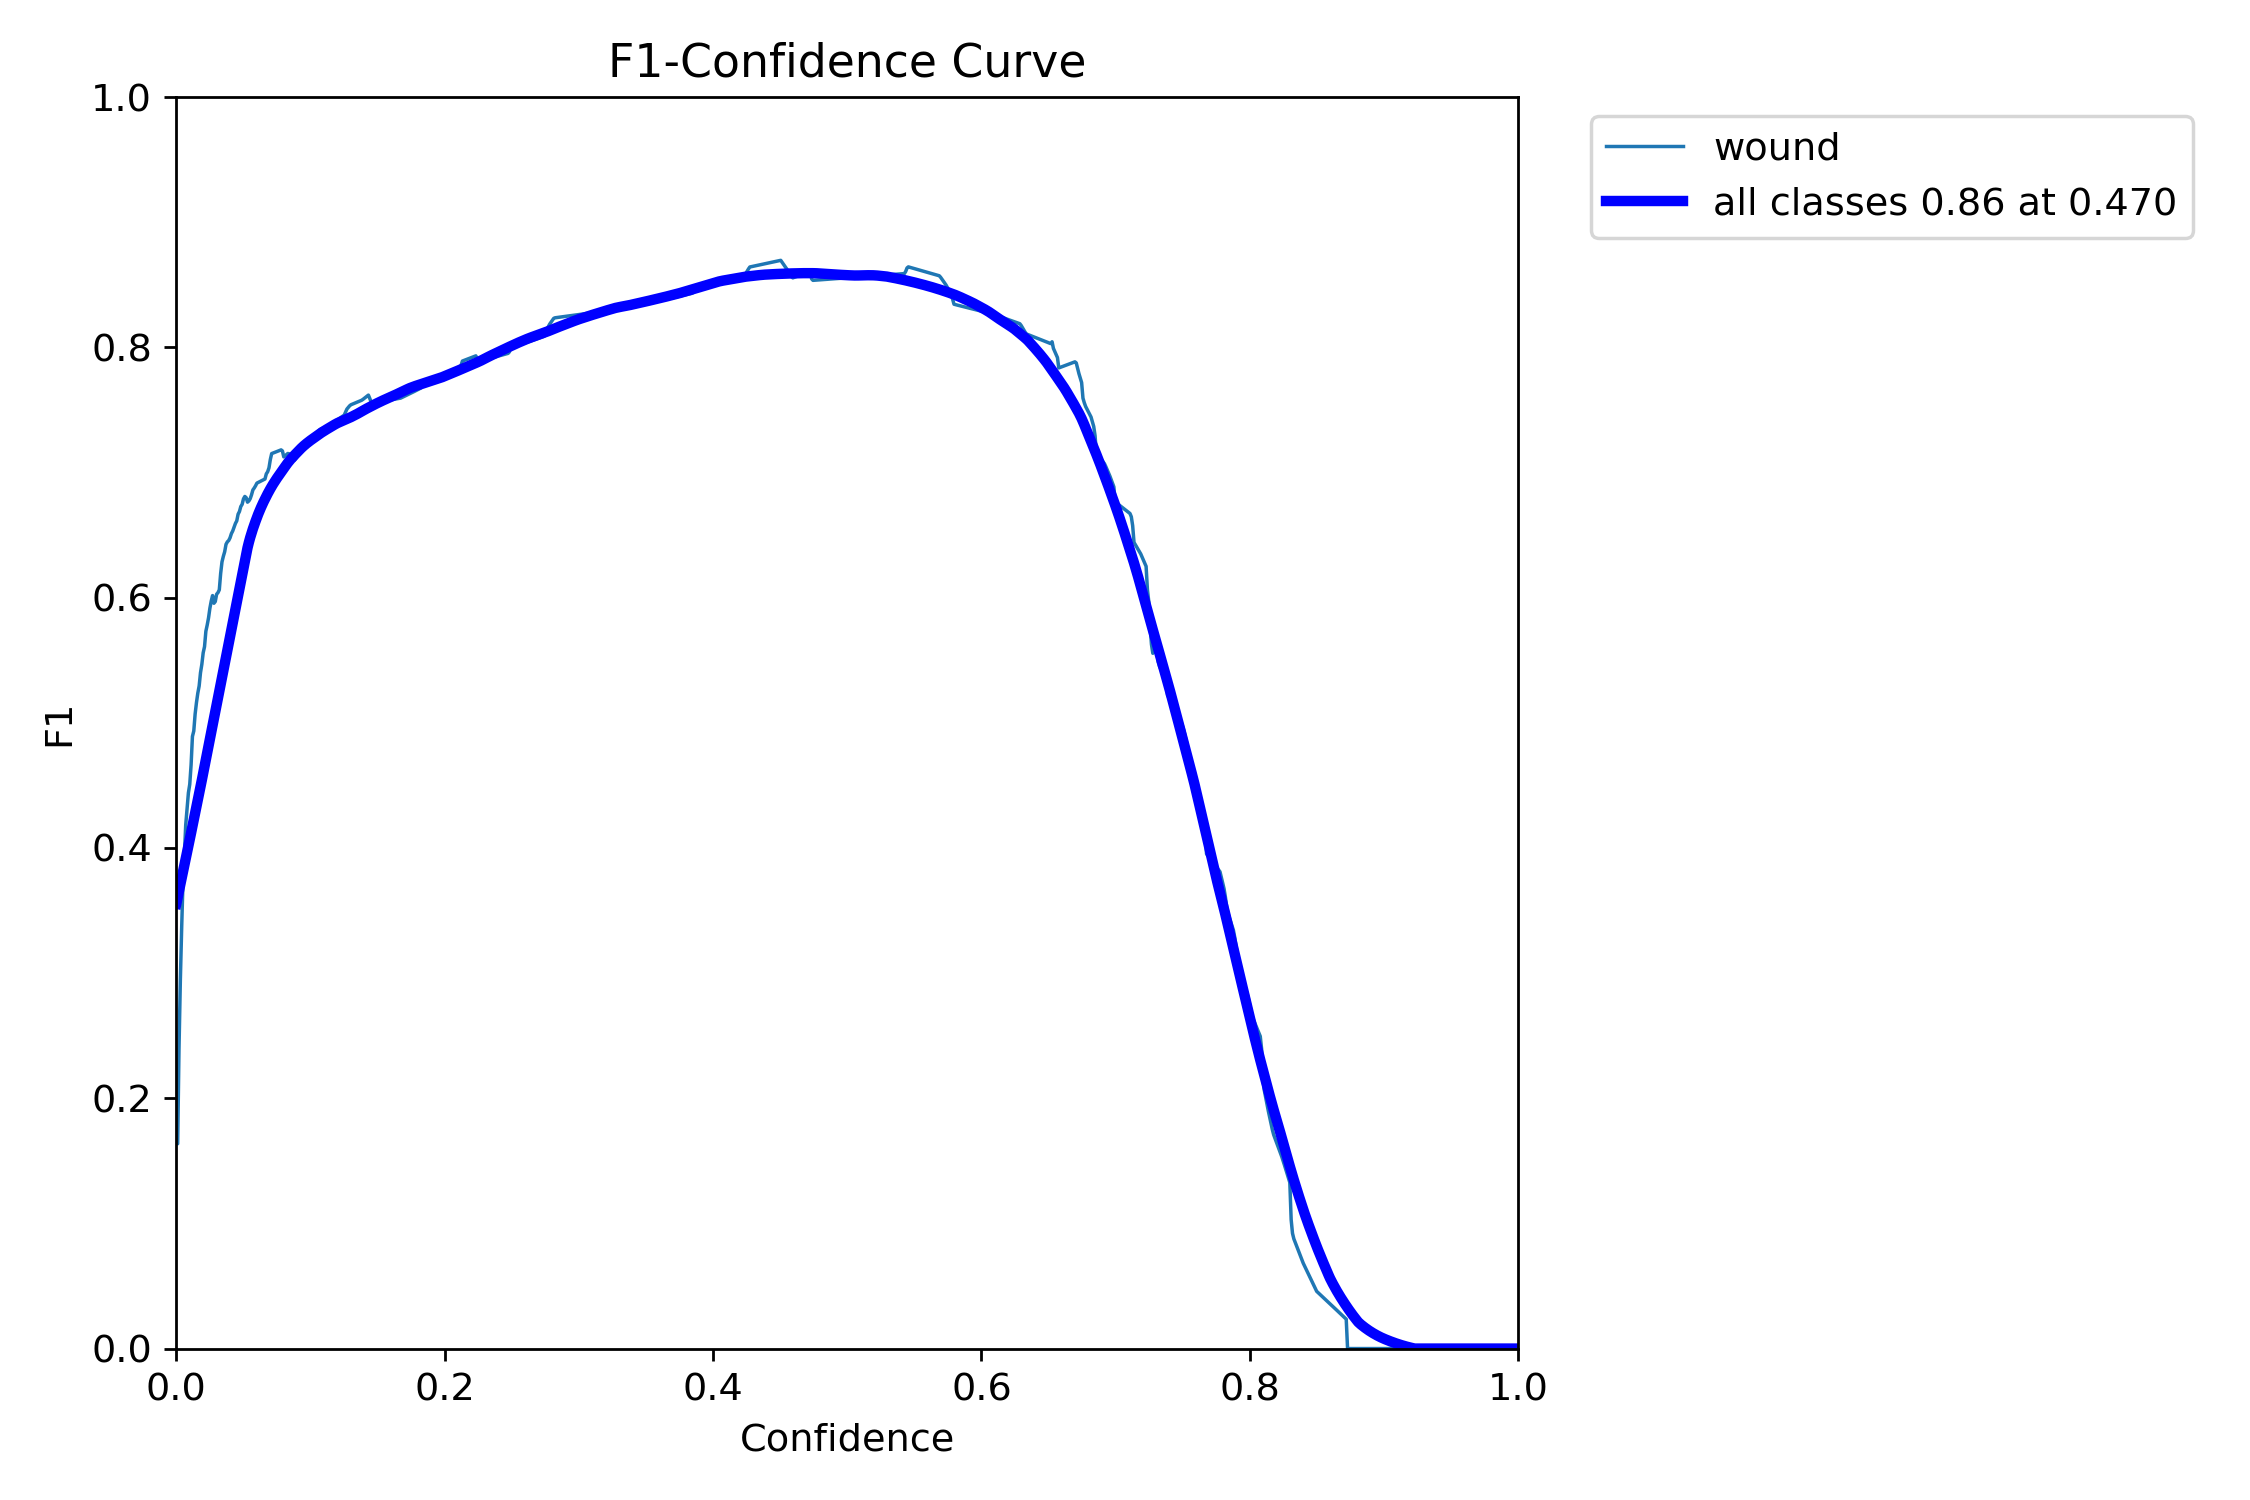


--- BoxP_curve.png ---


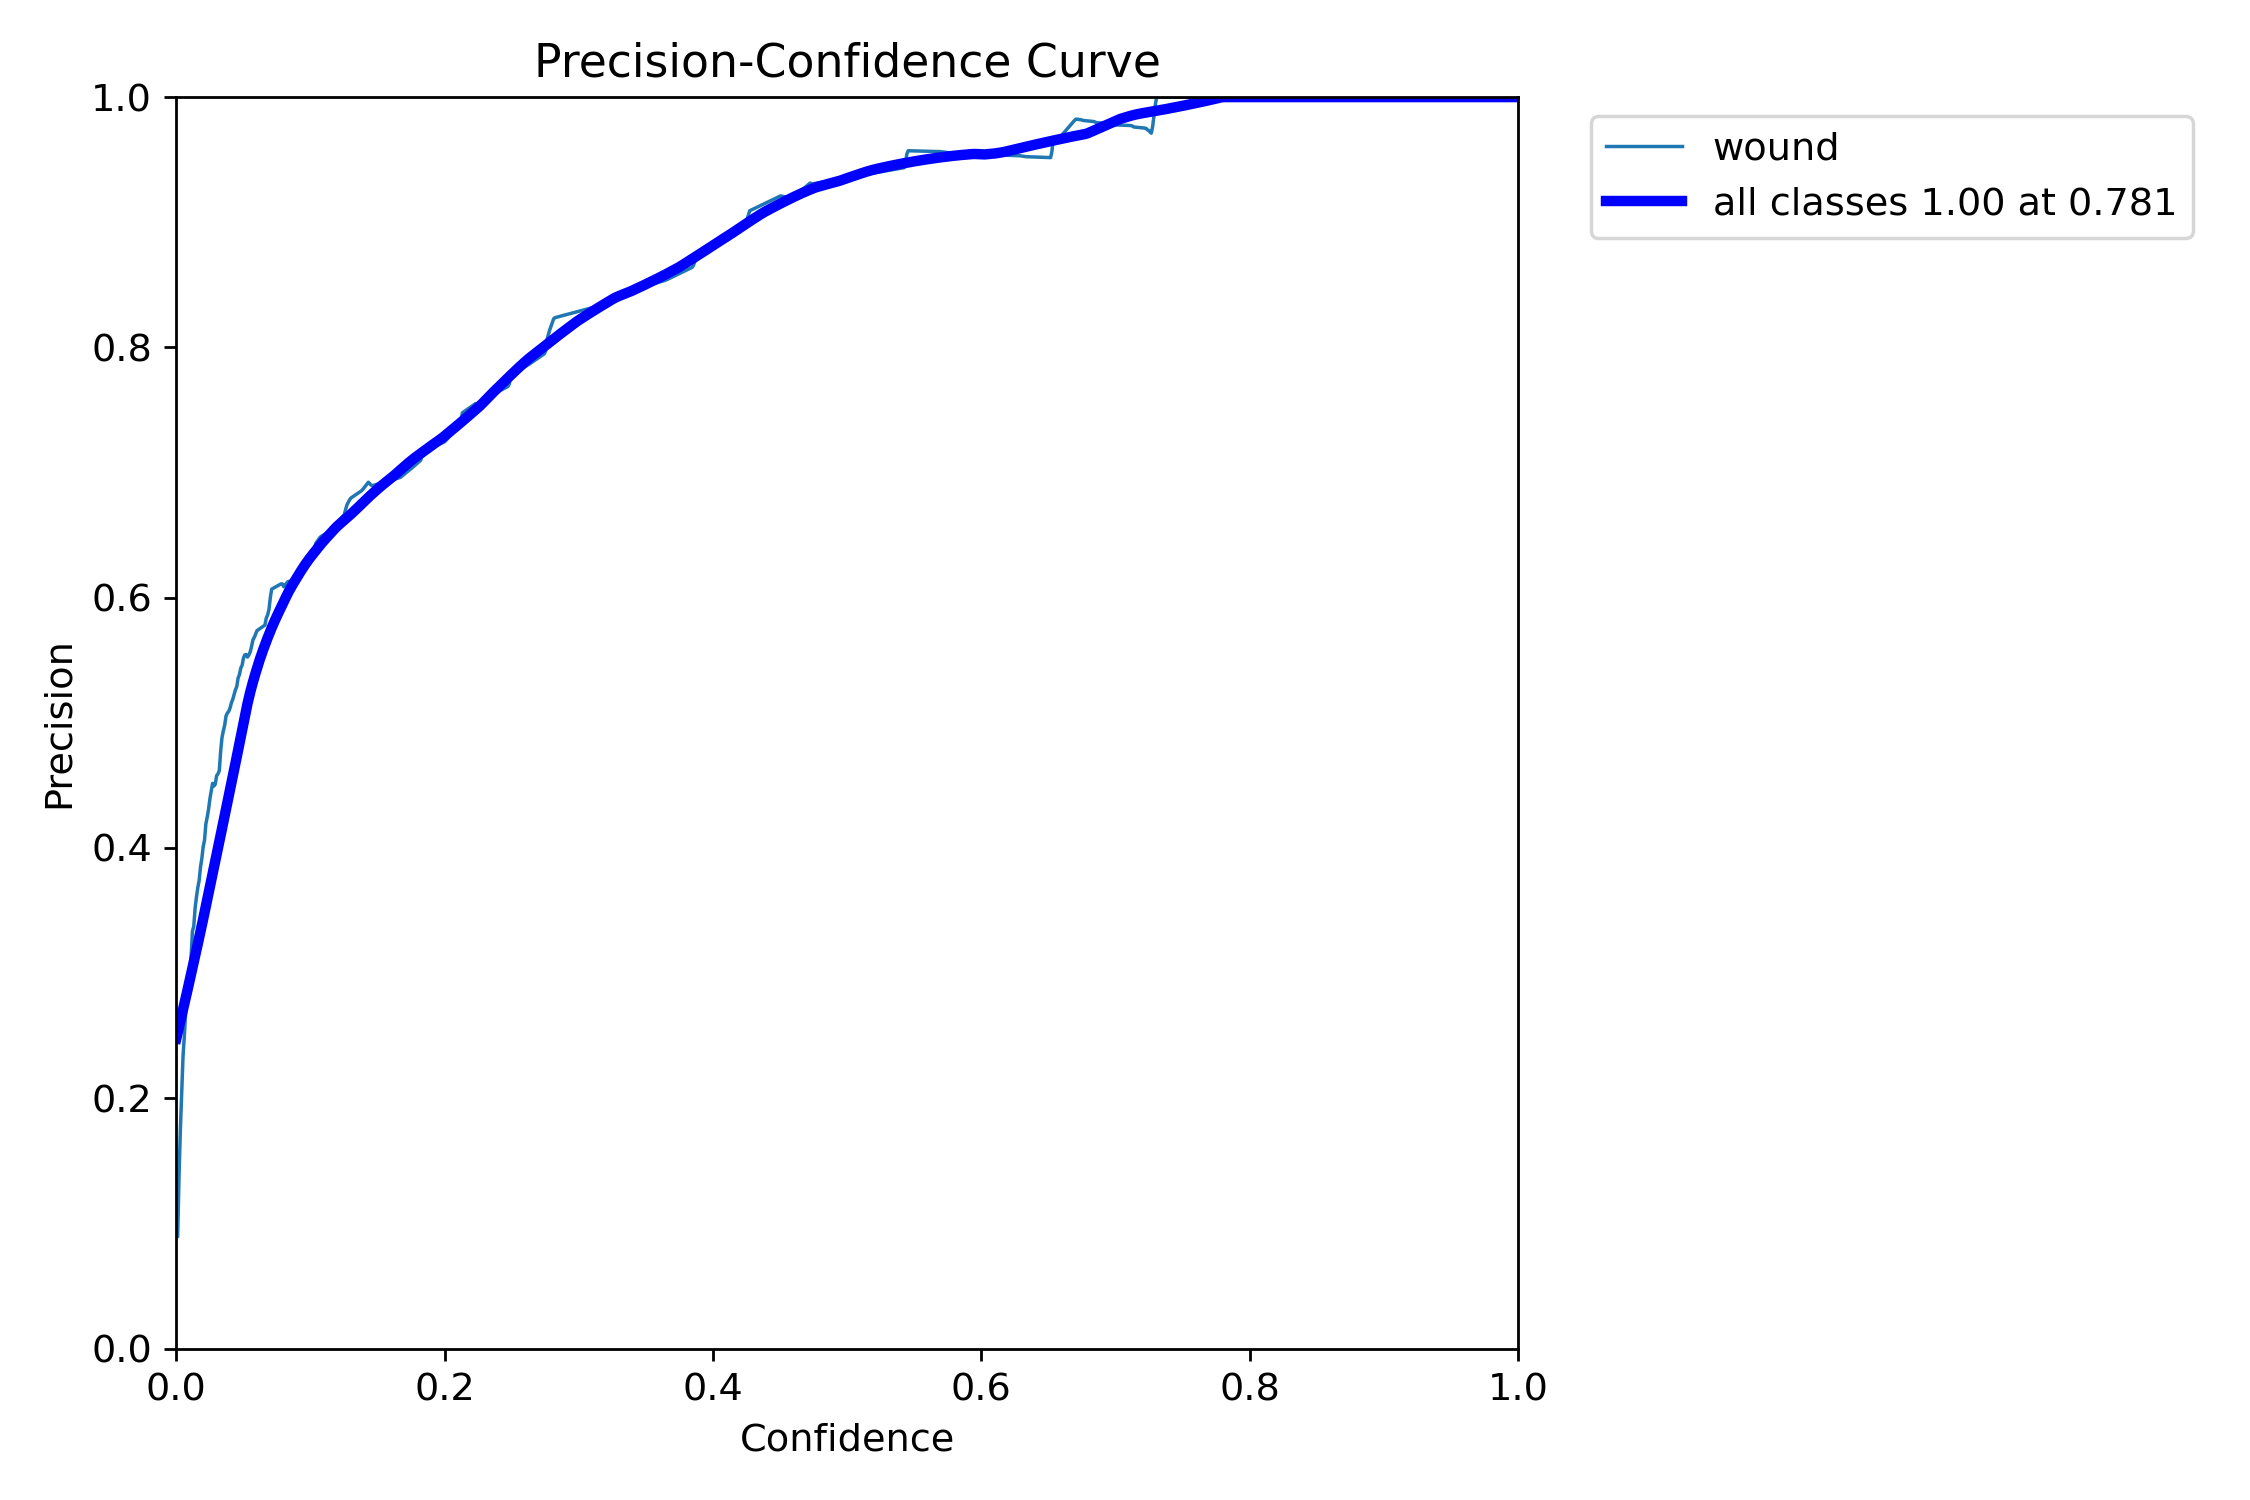


--- BoxPR_curve.png ---


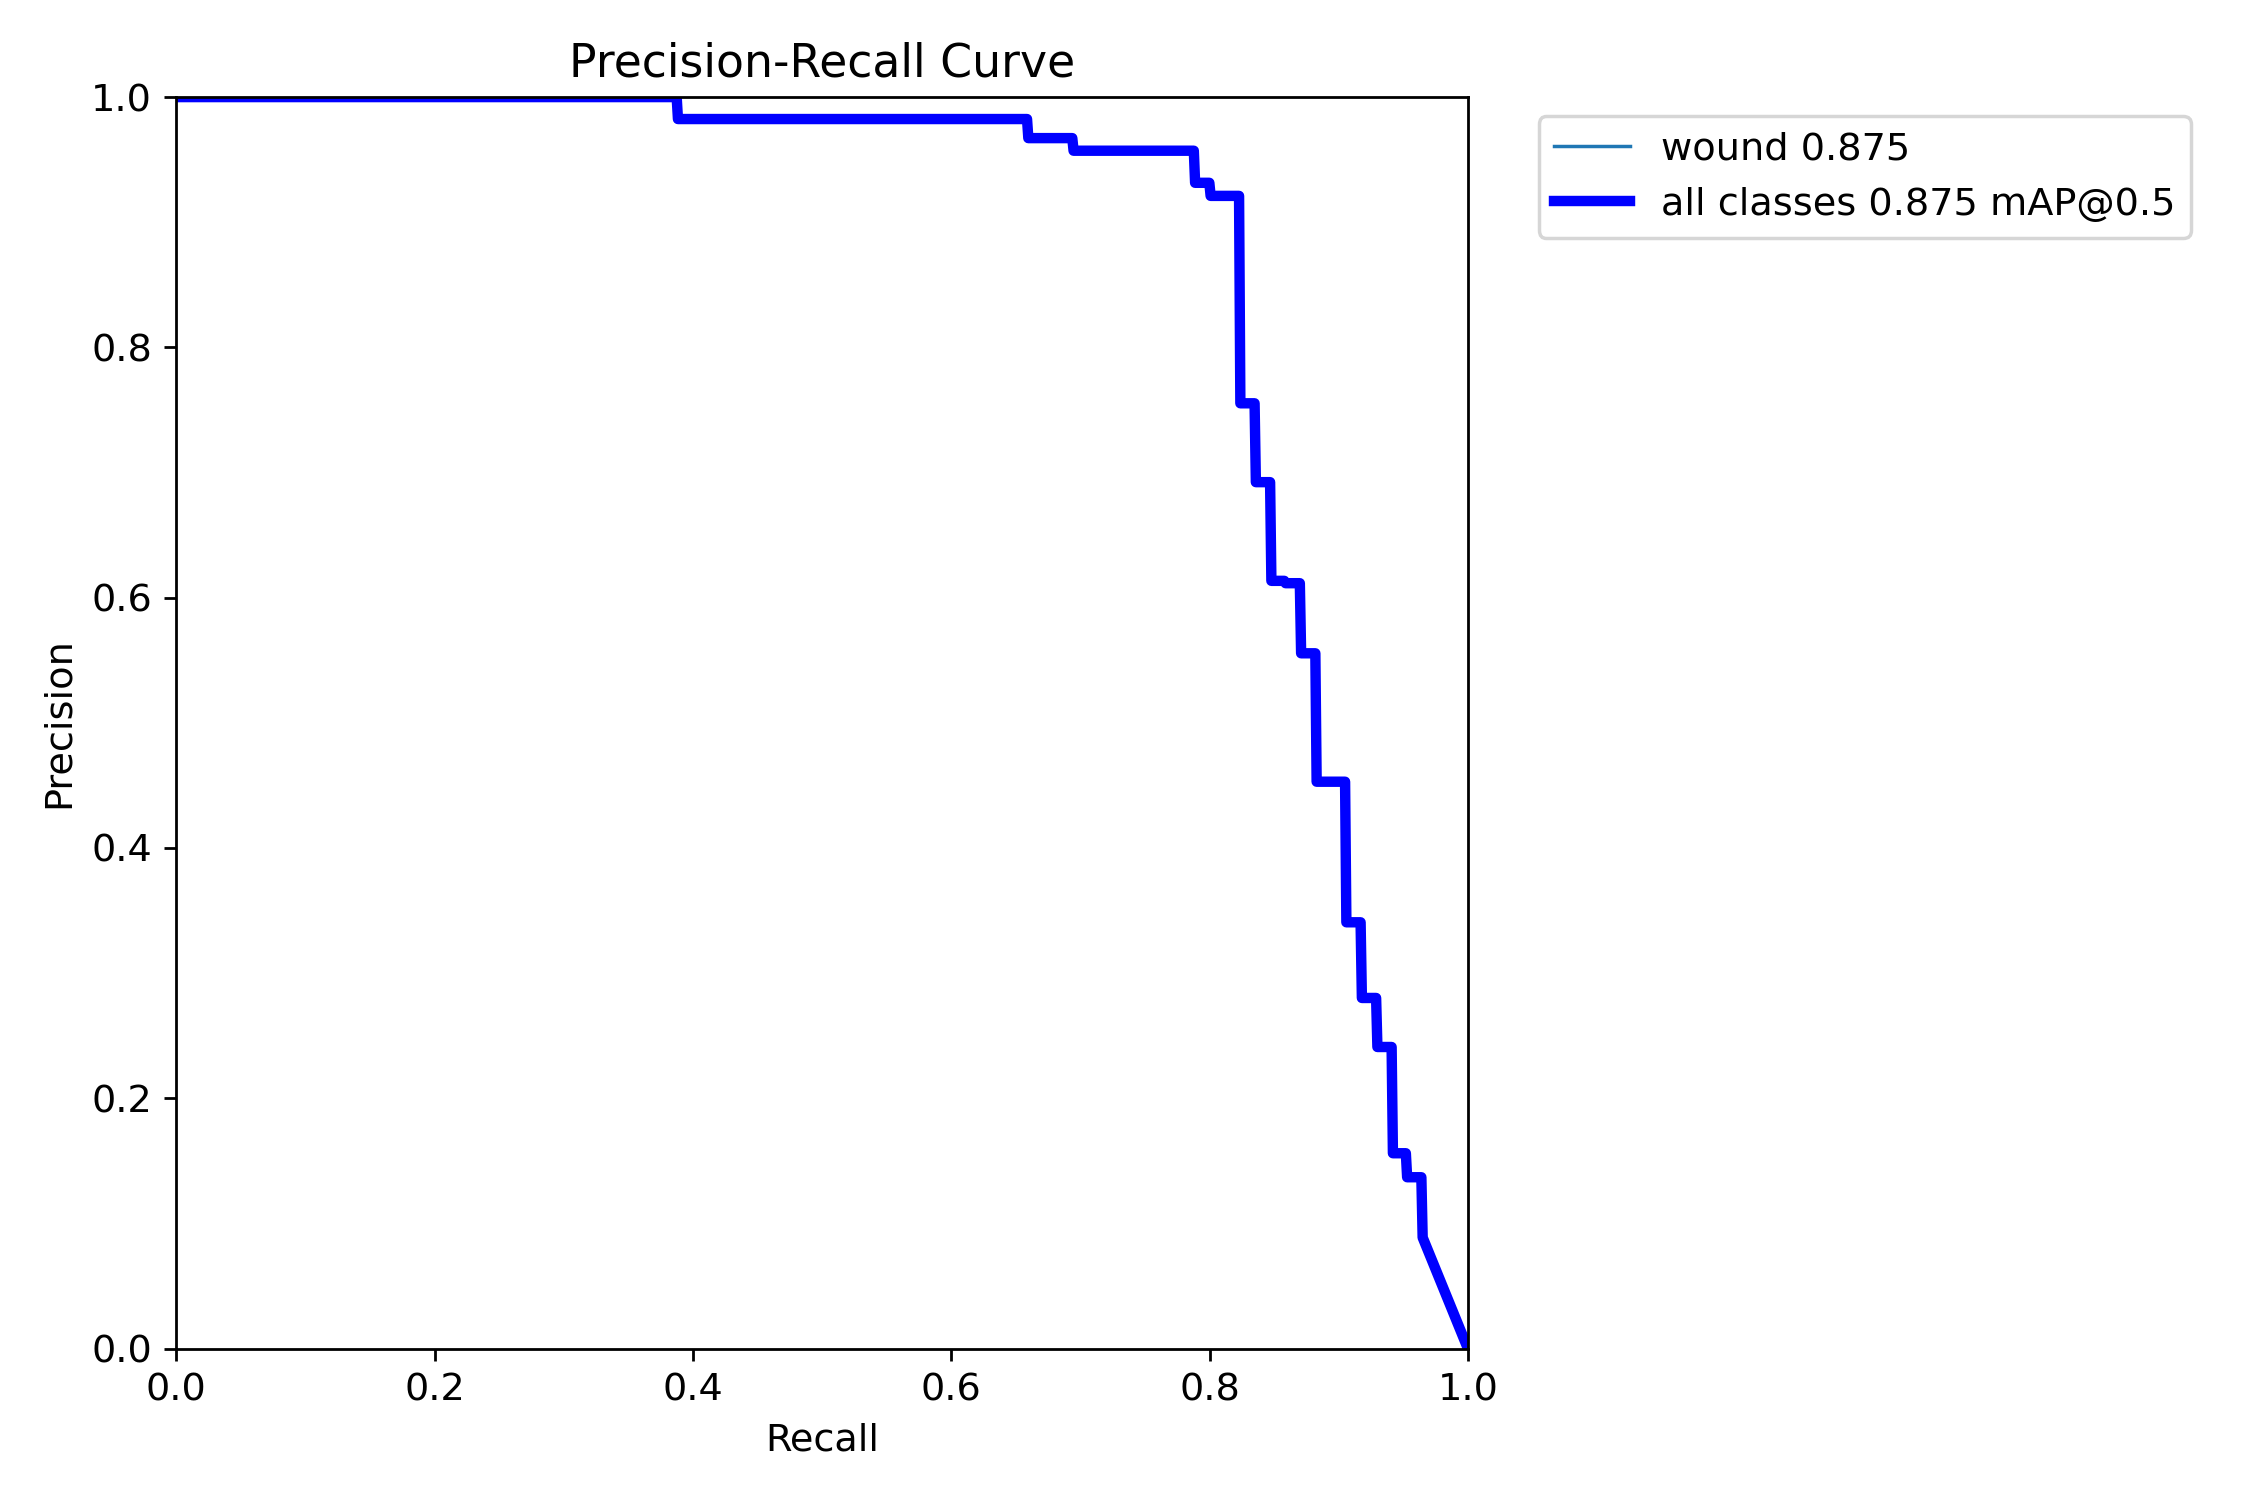


--- BoxR_curve.png ---


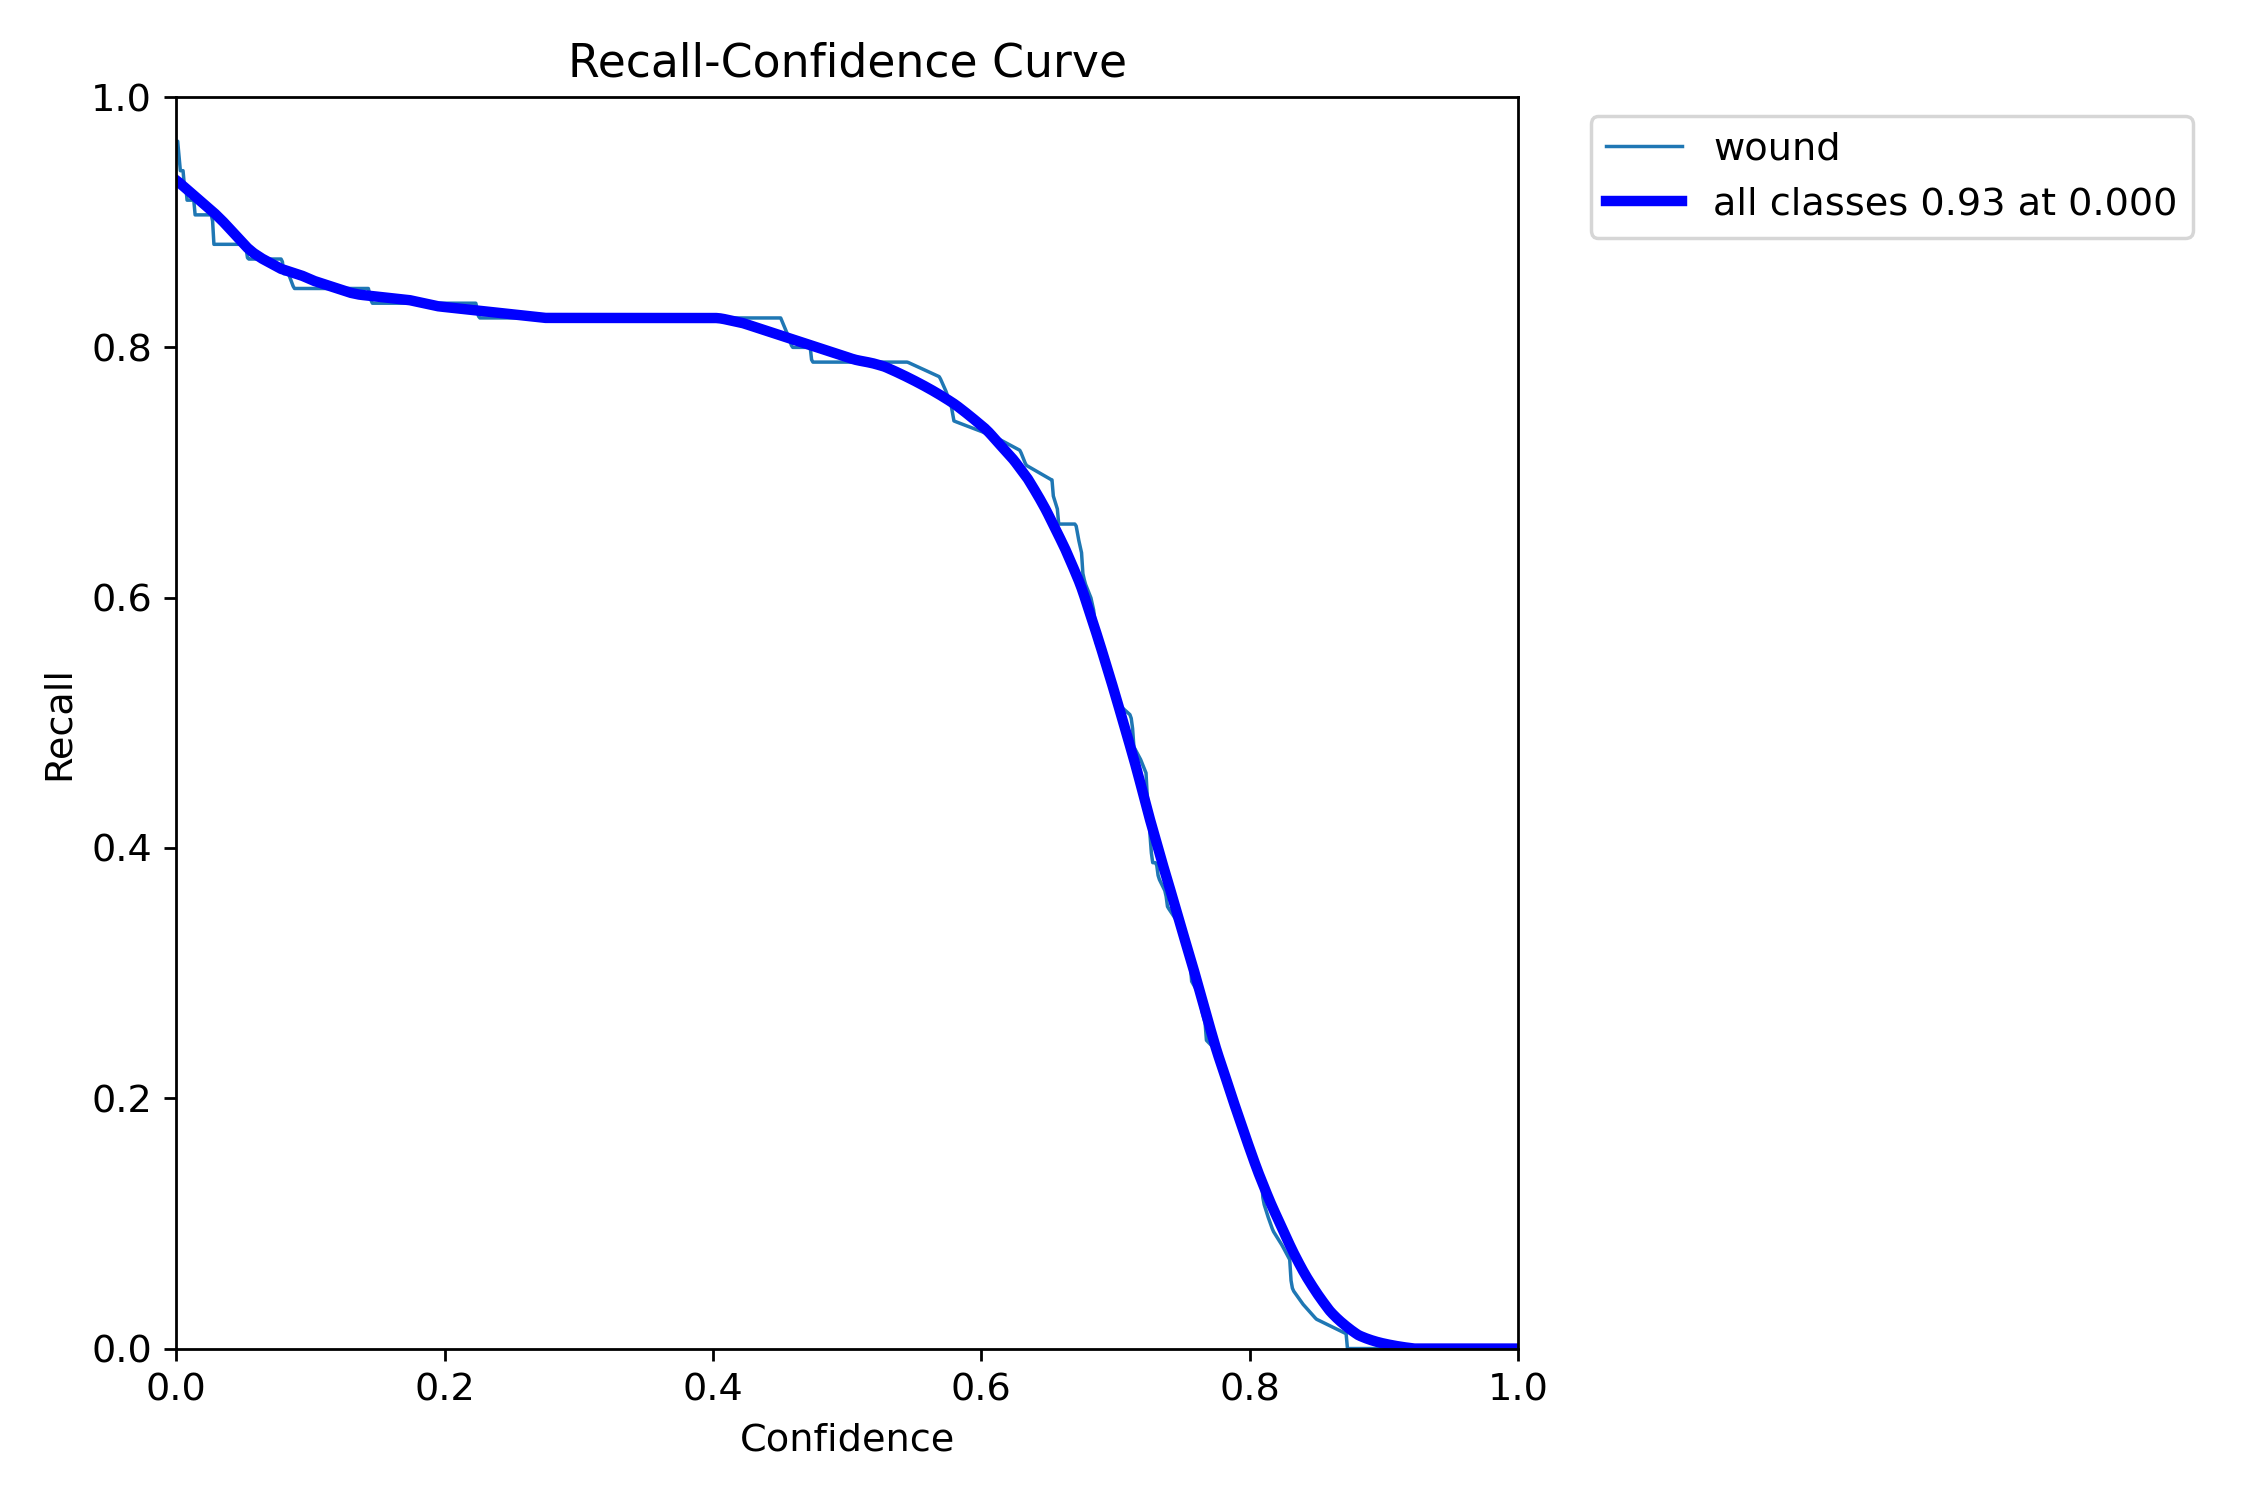


--- confusion_matrix.png ---


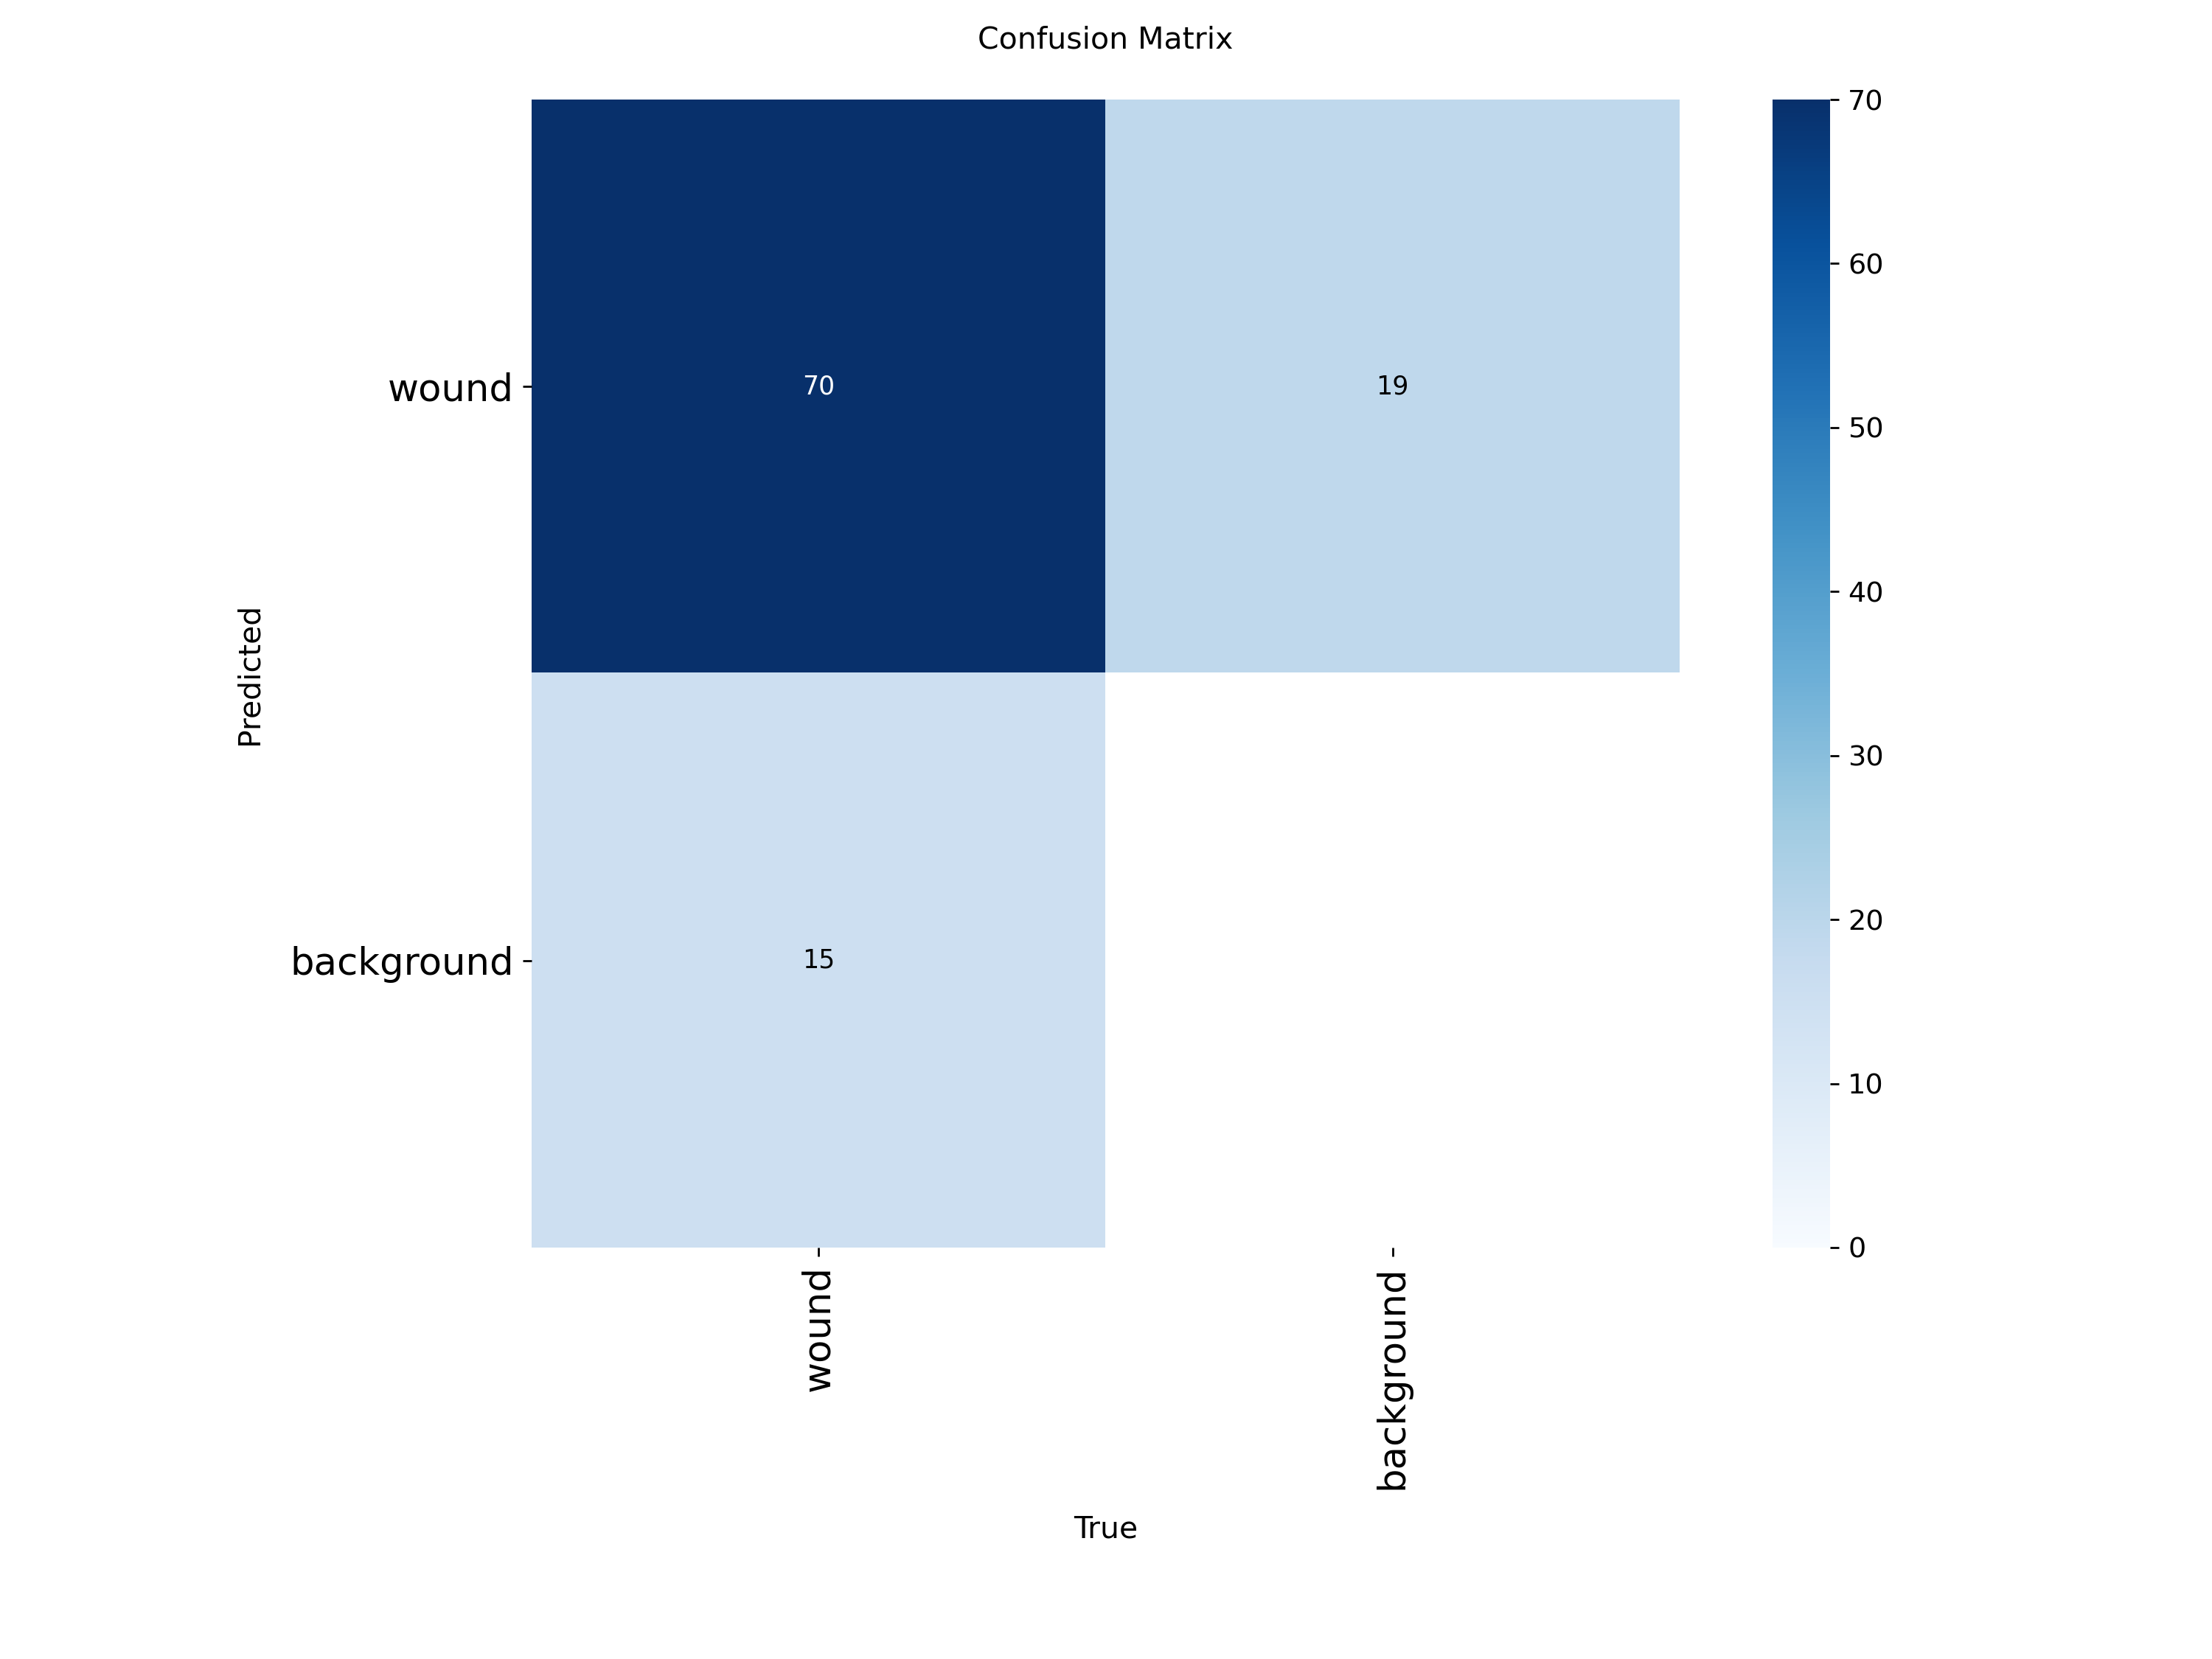


--- confusion_matrix_normalized.png ---


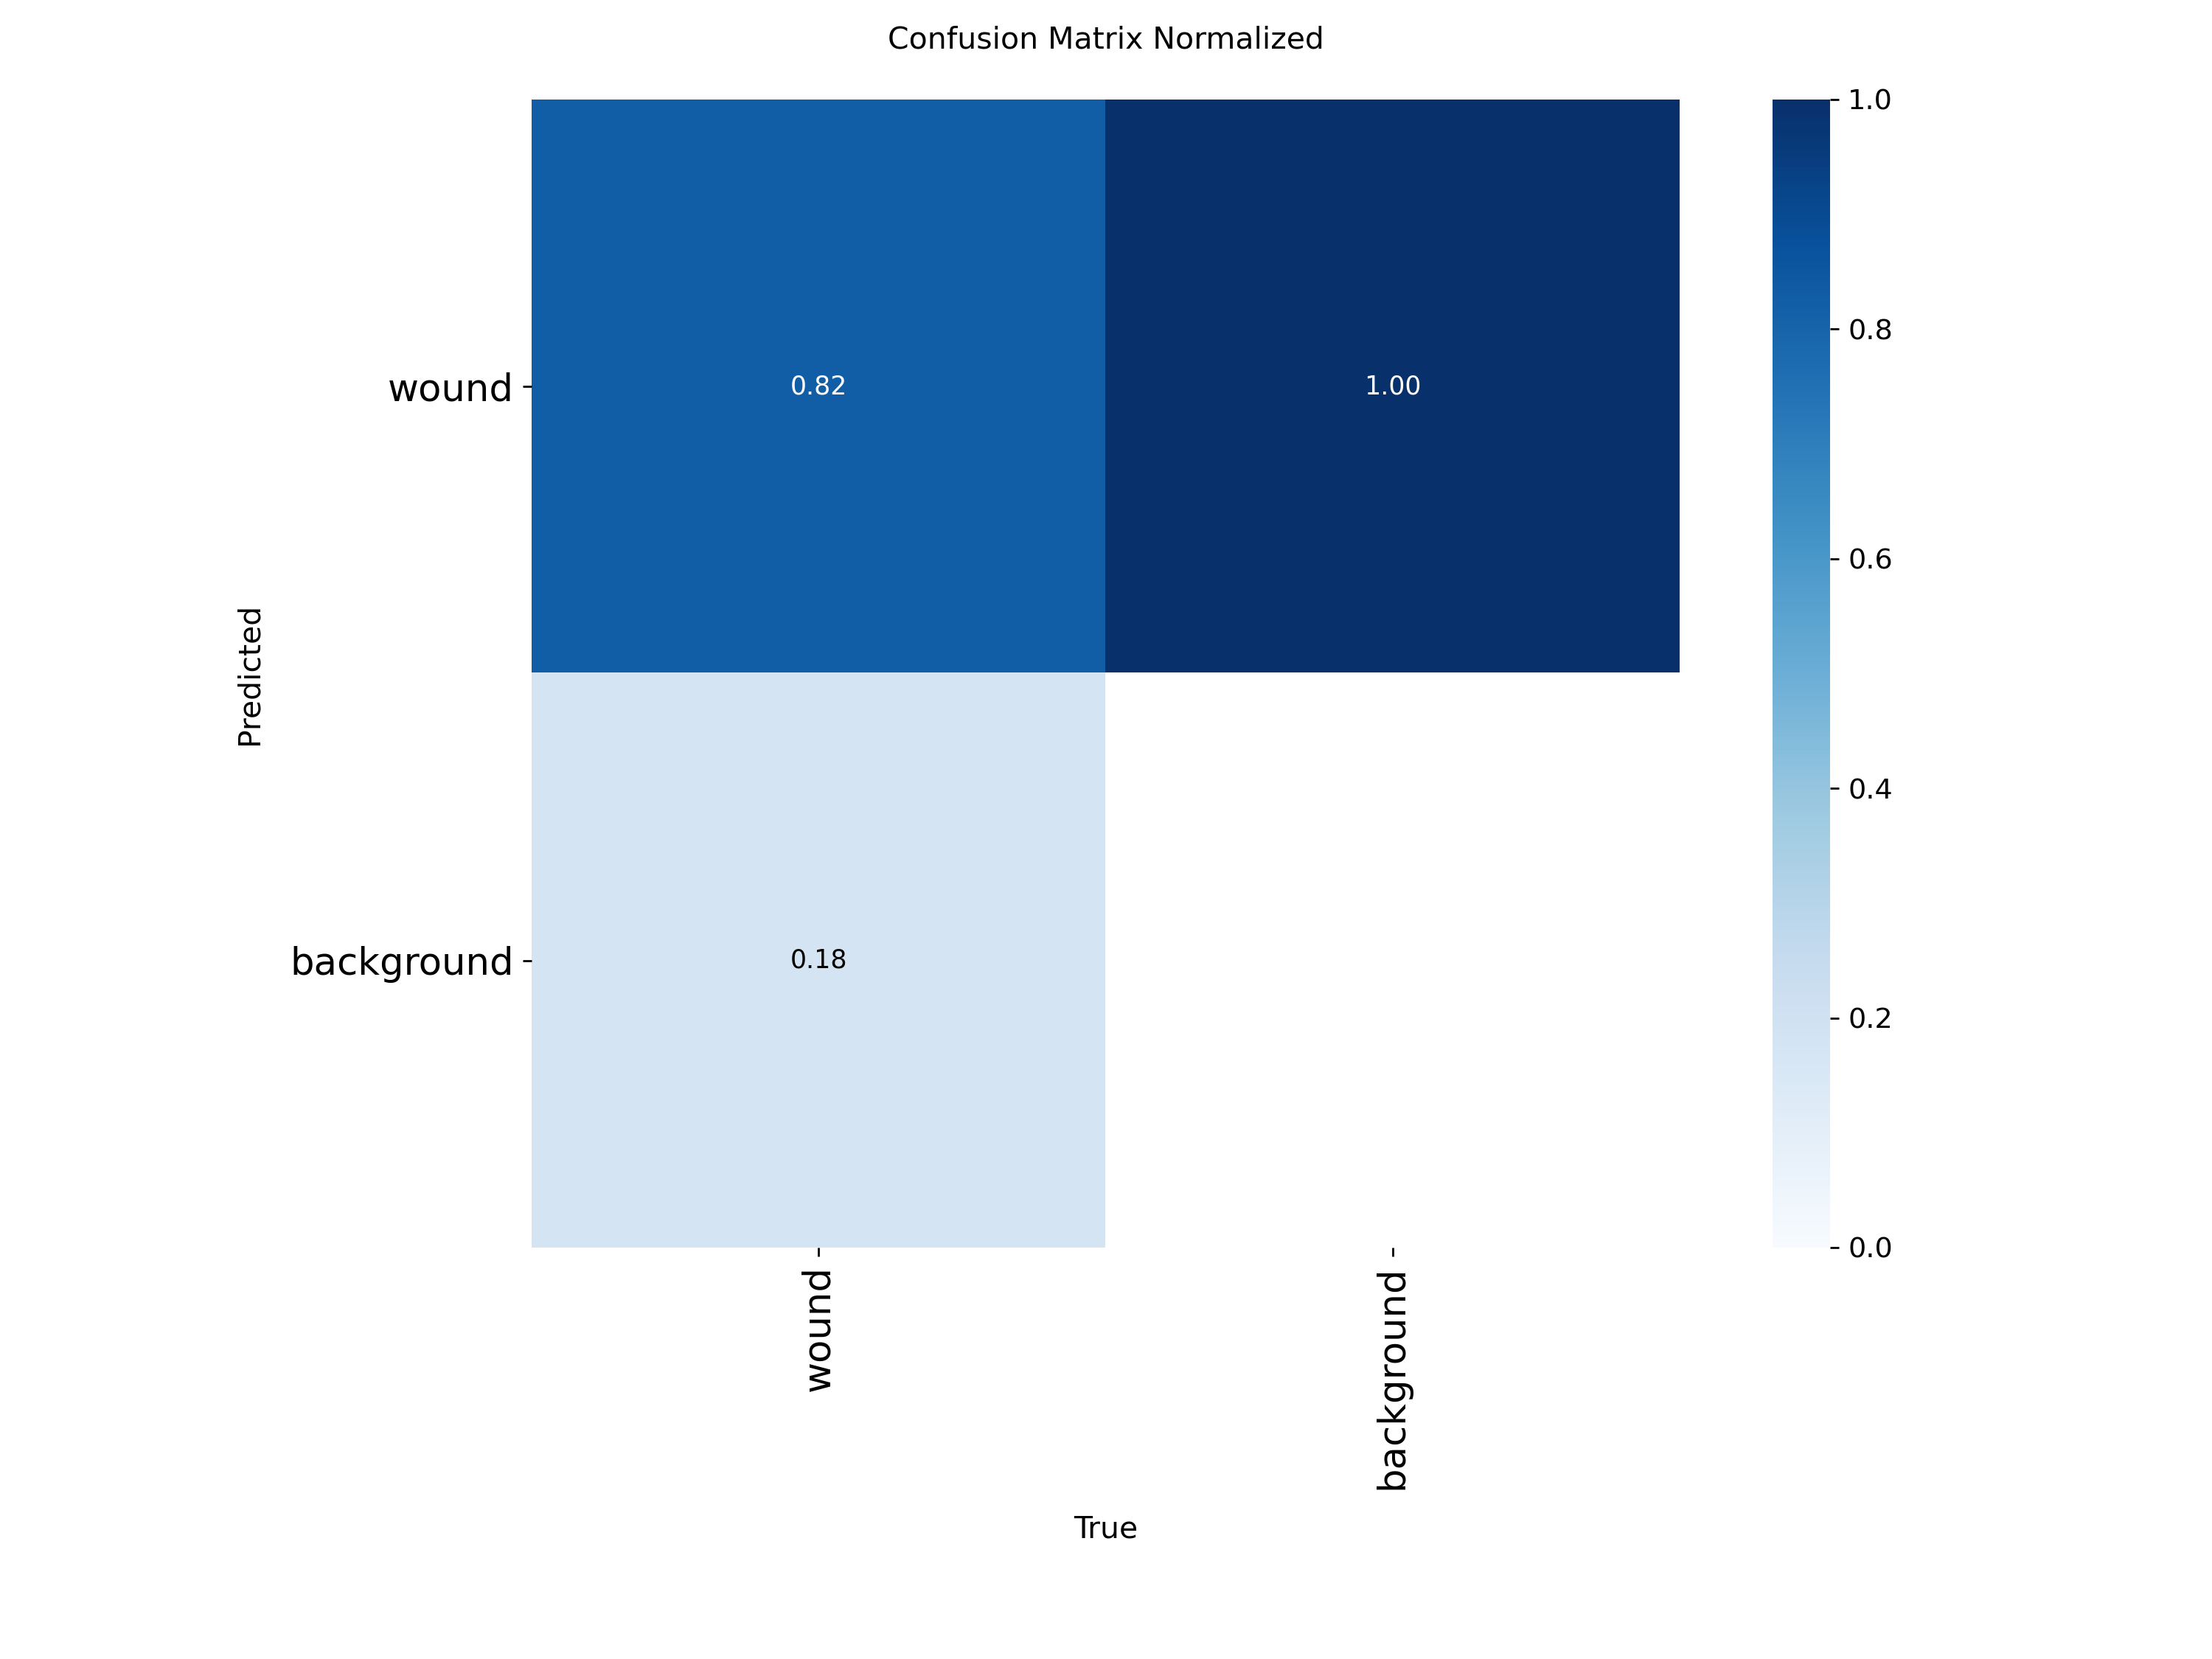


QUALITATIVE PREDICTIONS


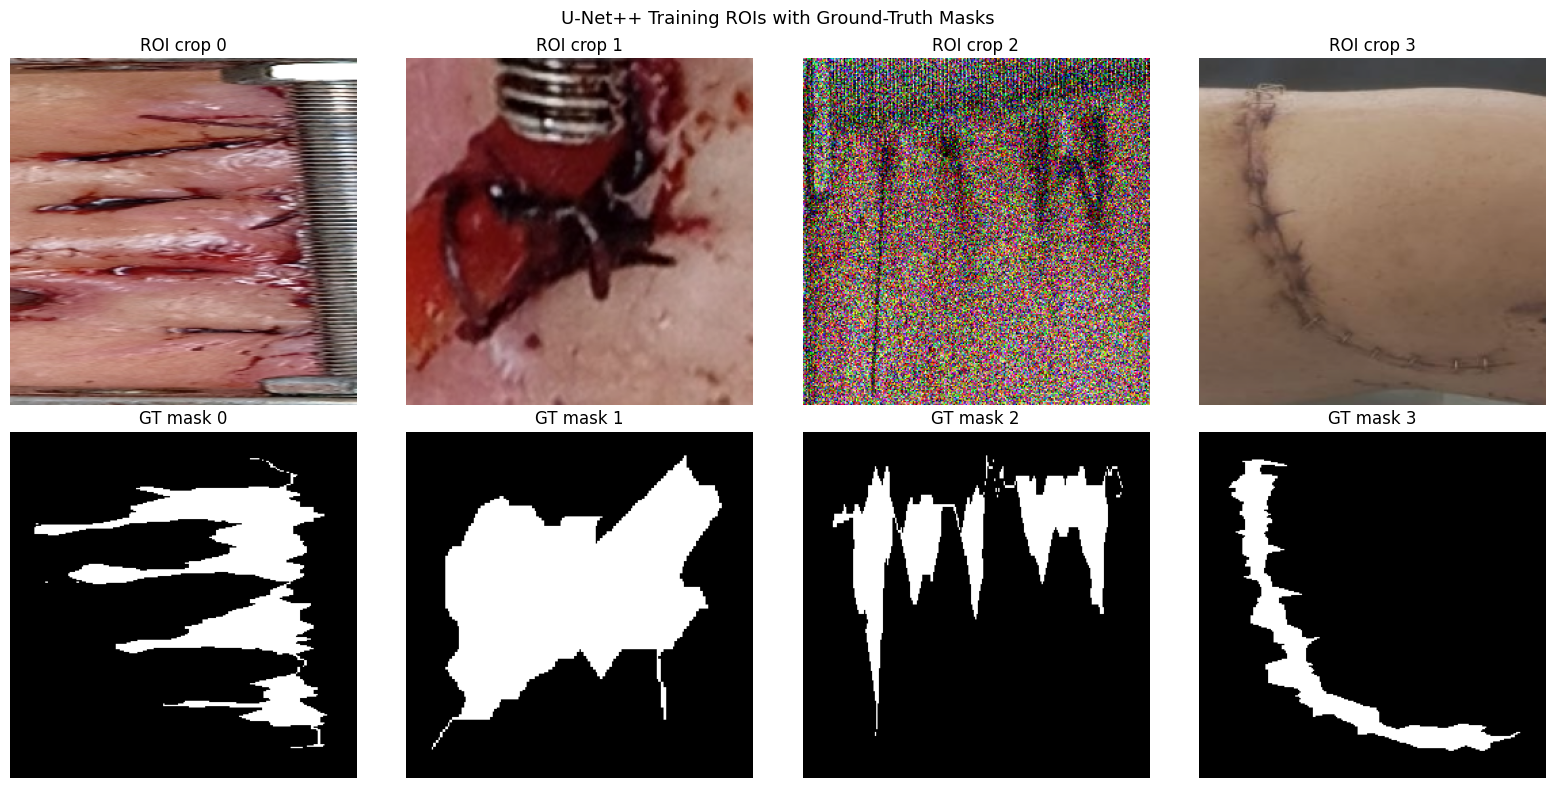

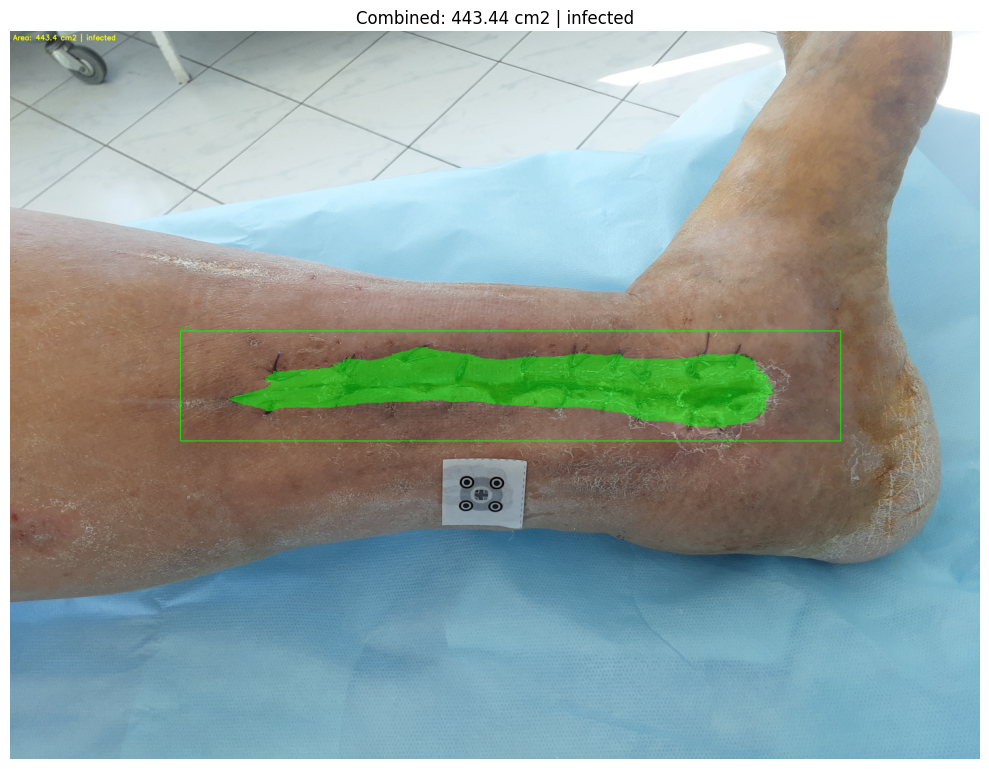

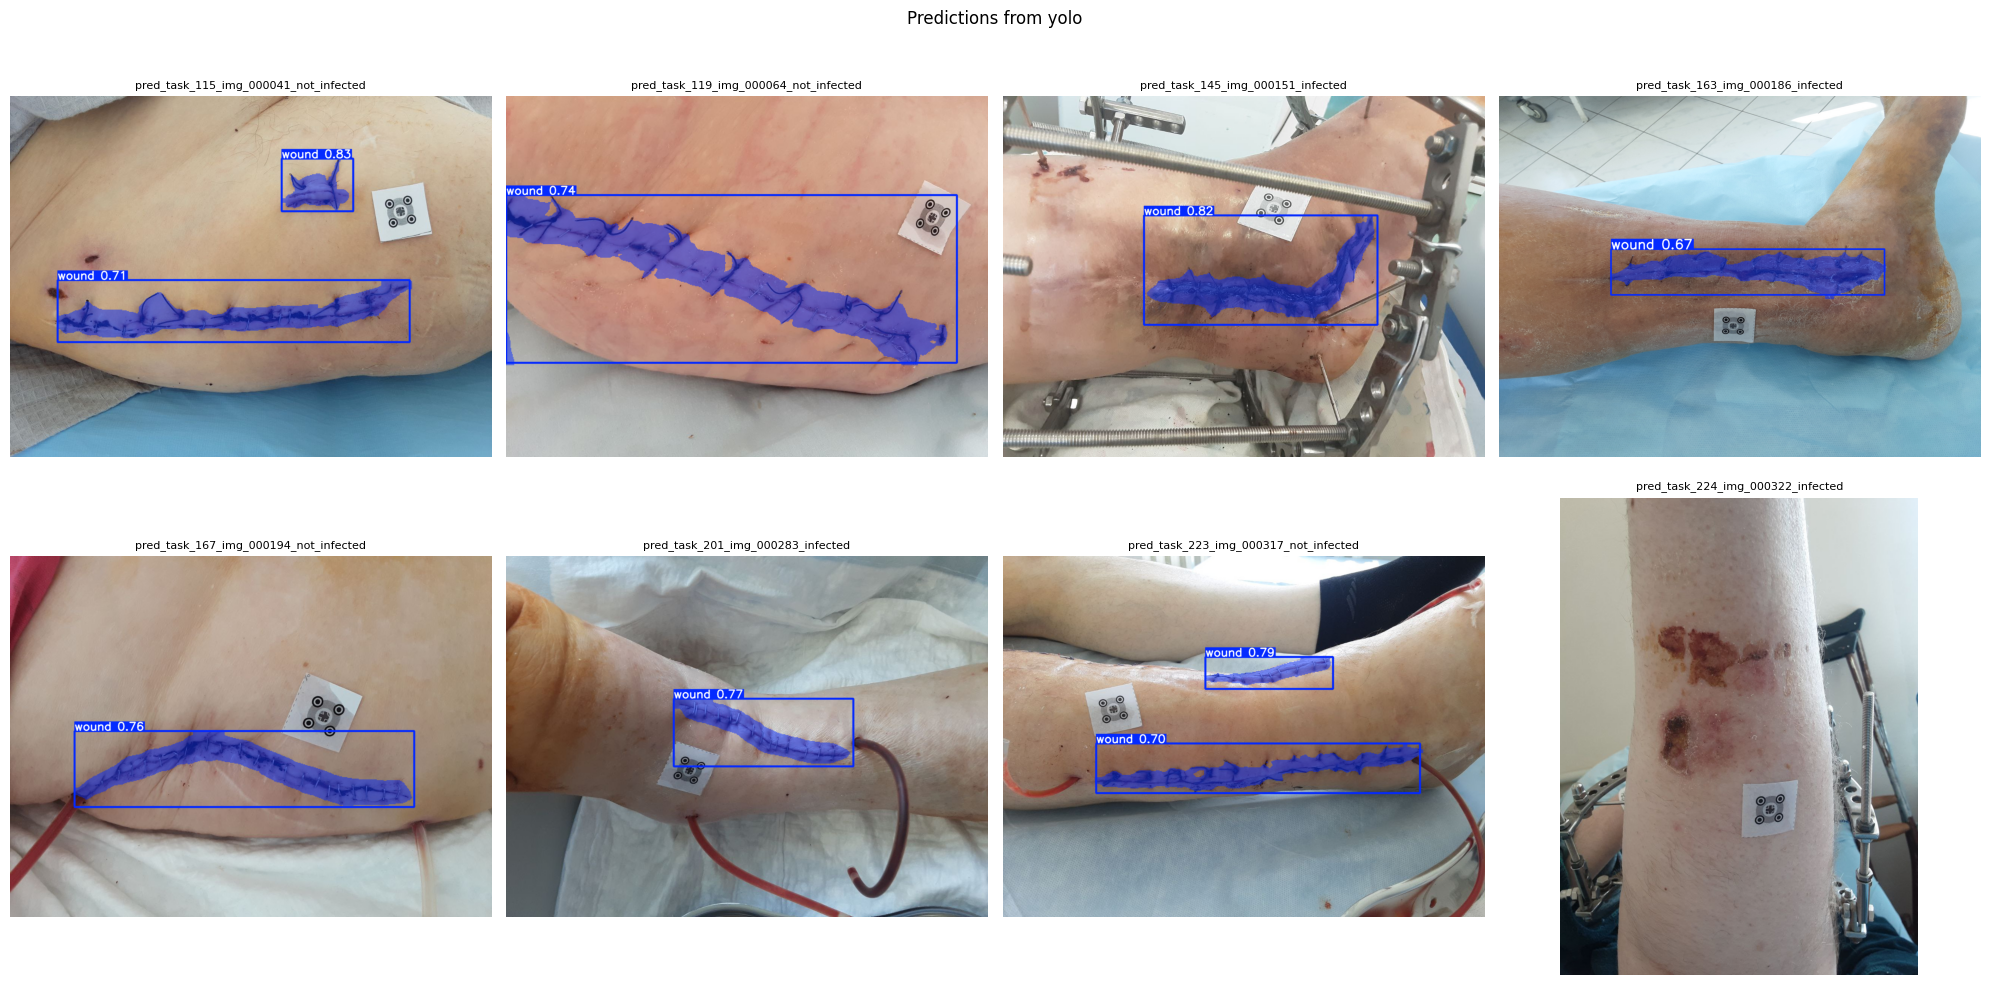


TRAINING REPORT


# YOLO11m + U-Net++ Training Report

Generated: 2026-03-30 00:06:49

---

## Configuration

### YOLO

| Parameter | Value |
|-----------|-------|
| model | yolo11m-seg.pt |
| image_size | 640 |
| batch_size | 8 |
| epochs | 100 |
| lr0 | 0.01 |
| lrf | 0.01 |
| optimizer | SGD |
| momentum | 0.937 |
| weight_decay | 0.0005 |
| patience | 20 |
| degrees | 10 |
| perspective | 0.0 |
| flipud | 0.5 |
| fliplr | 0.5 |
| mosaic | 1.0 |
| mixup | 0.1 |
| hsv_h | 0.015 |
| hsv_s | 0.7 |
| hsv_v | 0.4 |

### UNET

| Parameter | Value |
|-----------|-------|
| encoder | efficientnet-b3 |
| encoder_weights | imagenet |
| input_size | [256, 256] |
| in_channels | 3 |
| classes | 1 |
| batch_size | 16 |
| epochs | 50 |
| lr | 0.0001 |
| weight_decay | 0.0001 |
| optimizer | AdamW |
| scheduler | CosineAnnealingLR |
| scheduler_T_max | 50 |
| scheduler_eta_min | 1e-06 |
| early_stop_patience | 10 |
| loss_bce_weight | 0.5 |
| loss_dice_weight | 0.5 |
| roi_padding | 0.1 |

### COMBINED

| Parameter | Value |
|-----------|-------|
| yolo_conf_thresh | 0.5 |
| unet_mask_thresh | 0.5 |
| roi_padding | 0.1 |
| pixels_per_cm | 26.0 |
| num_qualitative_samples | 8 |


---

## YOLO11m-seg Results

| Metric | Value |
|--------|-------|
| epoch | 75.0000 |
| time | 1444.2700 |
| train/box_loss | 1.1418 |
| train/seg_loss | 2.4741 |
| train/cls_loss | 0.6723 |
| train/dfl_loss | 1.0943 |
| train/sem_loss | 0.0000 |
| metrics/precision(B) | 0.9262 |
| metrics/recall(B) | 0.7765 |
| metrics/mAP50(B) | 0.8685 |
| metrics/mAP50-95(B) | 0.5193 |
| metrics/precision(M) | 0.8442 |
| metrics/recall(M) | 0.6941 |
| metrics/mAP50(M) | 0.7270 |
| metrics/mAP50-95(M) | 0.2148 |
| val/box_loss | 1.4622 |
| val/seg_loss | 2.8784 |
| val/cls_loss | 0.8736 |
| val/dfl_loss | 1.2819 |
| val/sem_loss | 0.0000 |
| lr/pg0 | 0.0027 |
| lr/pg1 | 0.0027 |
| lr/pg2 | 0.0027 |
| training_completed | True |
| bbox_mAP50 | 0.7636 |
| bbox_mAP50_95 | 0.4940 |
| segm_mAP50 | 0.6230 |
| segm_mAP50_95 | 0.2348 |
| combined_AP50 | 0.6933 |

---

## U-Net++ Results

- **Best Dice (val):** 0.7737 at epoch 13
- **Training time:** 496s

### Test Metrics

| Metric | Value |
|--------|-------|
| dice | 0.7679 |
| iou | 0.6371 |
| pixel_accuracy | 0.8751 |

---

## Combined Pipeline Results

| Metric | Value |
|--------|-------|
| mean_dice | 0.6800 |
| mean_iou | 0.5508 |
| n_images_evaluated | 50 |
| n_predictions_saved | 8 |


CHECKPOINTS

  yolo/
    best.pt (43.1 MB)
    last.pt (43.1 MB)

  unet/
    best_model.pth (152.3 MB)
    last_checkpoint.pth (152.3 MB)


In [7]:
%matplotlib inline
import json
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

SCRIPT_DIR = Path.cwd().resolve()
sys.path.insert(0, str(SCRIPT_DIR))
from train_model import display_results_curves, display_results_predictions

RESULTS_DIR = SCRIPT_DIR / "results"
REPORTS_DIR = SCRIPT_DIR / "reports"
CHECKPOINTS_DIR = SCRIPT_DIR / "checkpoints"

# ============================================================================
# 6.1 Global Metrics Summary
# ============================================================================

metrics_file = RESULTS_DIR / "metrics_summary.json"
if metrics_file.exists():
    with open(metrics_file, "r", encoding="utf-8") as f:
        all_metrics = json.load(f)

    print("=" * 60)
    print("GLOBAL METRICS SUMMARY")
    print("=" * 60)

    yolo_m = all_metrics.get("yolo", {})
    if yolo_m:
        print("\n--- YOLO11m-seg ---")
        for k in ["bbox_mAP50", "bbox_mAP50_95", "segm_mAP50", "segm_mAP50_95", "combined_AP50"]:
            if k in yolo_m:
                print(f"  {k}: {yolo_m[k]:.4f}")

    unet_m = all_metrics.get("unet", {})
    if unet_m:
        print("\n--- U-Net++ ---")
        print(f"  Best Dice (val): {unet_m.get('best_dice', 'N/A')}")
        print(f"  Best epoch:      {unet_m.get('best_epoch', 'N/A')}")
        test_m = unet_m.get("test_metrics", {})
        for k in ["dice", "iou", "pixel_accuracy"]:
            if k in test_m:
                print(f"  Test {k}: {test_m[k]:.4f}")

    combined_m = all_metrics.get("combined", {})
    if combined_m:
        print("\n--- Combined Pipeline ---")
        for k in ["mean_dice", "mean_iou", "n_images_evaluated"]:
            if k in combined_m:
                v = combined_m[k]
                print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
else:
    print("No metrics_summary.json found. Run training first.")

# ============================================================================
# 6.2 Training Curves
# ============================================================================

print("\n" + "=" * 60)
print("TRAINING CURVES")
print("=" * 60)
display_results_curves(RESULTS_DIR)

# ============================================================================
# 6.3 Qualitative Predictions
# ============================================================================

print("\n" + "=" * 60)
print("QUALITATIVE PREDICTIONS")
print("=" * 60)
display_results_predictions(RESULTS_DIR)

# ============================================================================
# 6.4 Training Report
# ============================================================================

report_file = REPORTS_DIR / "training_report.md"
if report_file.exists():
    print("\n" + "=" * 60)
    print("TRAINING REPORT")
    print("=" * 60)
    with open(report_file, "r", encoding="utf-8") as f:
        display(Markdown(f.read()))

# ============================================================================
# 6.5 Checkpoint info
# ============================================================================

print("\n" + "=" * 60)
print("CHECKPOINTS")
print("=" * 60)
for subdir in ["yolo", "unet"]:
    d = CHECKPOINTS_DIR / subdir
    if d.exists():
        files = list(d.glob("*"))
        print(f"\n  {subdir}/")
        for fp in sorted(files):
            if fp.is_file():
                size_mb = fp.stat().st_size / (1024 * 1024)
                print(f"    {fp.name} ({size_mb:.1f} MB)")